In [1]:
import pandas as pd
import numpy as np
from mysqldatabase import *
import os
import random
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

#### Importing from database

In [2]:
dbo =  Database()
tablets = dbo.import_table("tablets_uncleaned")
dbo.close()

#### Dirty Data Issues:
- Completness:
    <ul> Missing Values in:
        <ul>connectivity</ul>
        <ul>spec_score</ul>
        <ul>user_rating</ul>
        <ul>cpu</ul>
        <ul>ram</ul>
        <ul>battery</ul>
        <ul>display</ul>
        <ul>camera</ul>
        <ul>expandable</ul>
        <ul>os (maybe try using brand name to impute into nulls)</ul>
        <ul>fm_radio</ul>
        <ul>other</ul>
    </ul>
    <ul> There is no need for kindles. Delete their rows. (keep kindle fire)</ul>
- Validity:
    <ul>wrong data types for: 
        <ul>price</ul>
        <ul>spec_score</ul>
        <ul>all new columns</ul>
    </ul>
    <ul> 64 duplicates when using the subset (name, price) </ul>
    <ul> take the average price of "Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi + 128GB)"'s duplicate rows. </ul>
- Accuracy:
    <ul></ul>
- Consistency:
    <ul>many values are repeating with different names in the following columns:
        <ul>os</ul>
        <ul>all new columns</ul>
    </ul>
    
#### Messy Data Issues:
- the following columns can be broken down into more columns or changed to a better format for better analysis:
  <ul>name</ul>
  <ul>connectivity</ul>
  <ul>cpu</ul>
  <ul>ram</ul>
  <ul>battery</ul>
  <ul>display</ul>
  <ul>camera</ul>
  <ul>expandable</ul>
  <ul>other</ul>
- fm_radio column does not provide any information, only 112 values present and all of them are "No FM Radio". Drop this column.
- rearrange the columns at the end.

### change price's datatype and check for outliers using describe and boxplots/kdeplots..


In [3]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1629 non-null   object 
 1   price         1629 non-null   object 
 2   spec_score    1620 non-null   float64
 3   user_rating   1622 non-null   float64
 4   connectivity  1341 non-null   object 
 5   cpu           1570 non-null   object 
 6   ram           1611 non-null   object 
 7   battery       1418 non-null   object 
 8   display       1617 non-null   object 
 9   camera        1621 non-null   object 
 10  expandable    1213 non-null   object 
 11  os            477 non-null    object 
 12  fm_radio      112 non-null    object 
 13  img           1629 non-null   object 
 14  other         1614 non-null   object 
dtypes: float64(2), object(13)
memory usage: 191.0+ KB


In [4]:
tablets.duplicated(subset=("name")).sum()

65

In [5]:
tablets.duplicated(subset=("name", "price")).sum()

64

In [6]:
name_price_mask = tablets.duplicated(subset=("name", "price"))
name_mask = tablets.duplicated(subset=("name"))

In [7]:
diff_df = tablets[name_mask].merge(
    tablets[name_price_mask],
    how="outer",
    indicator=True
)

result = diff_df[diff_df["_merge"] == "left_only"].drop(columns="_merge")

In [8]:
result

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,other
18,Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi ...,14999,65.0,4.75,NaN,"Helio P22T, Octa Core, 2 GHz Processor","4 GB RAM, 128 GB inbuilt",5000 mAh Battery,"10.3 inches, 1920 x 1200 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 256 GB",NaN,NaN,https://cdn1.smartprix.com/rx-i3PSt8PEa-w280-h...,Wi-Fi


In [9]:
tablets[tablets["name"] == result["name"].values[0]]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,other
246,Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi ...,17489,65.0,4.75,NaN,"Helio P22T, Octa Core, 2 GHz Processor","4 GB RAM, 128 GB inbuilt",5000 mAh Battery,"10.3 inches, 1920 x 1200 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 256 GB",NaN,NaN,https://cdn1.smartprix.com/rx-i3PSt8PEa-w280-h...,Wi-Fi
309,Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi ...,14999,65.0,4.75,NaN,"Helio P22T, Octa Core, 2 GHz Processor","4 GB RAM, 128 GB inbuilt",5000 mAh Battery,"10.3 inches, 1920 x 1200 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 256 GB",NaN,NaN,https://cdn1.smartprix.com/rx-i3PSt8PEa-w280-h...,Wi-Fi


In [10]:
tablets[tablets["name"].apply(lambda x: True if ("kindle fire" in (x.lower())) else False)]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,other
1203,Amazon Kindle Fire HD 7 Tablet (32GB),15999,44.0,2.35,No Sim Supported,"Dual Core, 1.2 GHz Processor","1 GB RAM, 32 GB inbuilt",NaN,"7 inches, 800 x 1280 px Display",1.3 MP Rear Camera,Memory Card Not Supported,Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-iesqImhwX-w280-h...,"Wi-Fi, HDMI"
1204,"Amazon Kindle Fire HD 8.9"" Tablet (16GB)",17999,47.0,3.95,No Sim Supported,"Dual Core, 1.5 GHz Processor","1 GB RAM, 16 GB inbuilt",NaN,"8.9 inches, 1920 x 1200 px Display",1.3 MP Rear Camera,Memory Card Not Supported,Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-iDLiXN48d-w280-h...,"Wi-Fi, HDMI"
1205,"Amazon Kindle Fire HD 7"" Tablet (16GB)",15999,42.0,4.05,No Sim Supported,"Dual Core, 1.2 GHz Processor","1 GB RAM, 16 GB inbuilt",NaN,"7 inches, 800 x 1280 px Display",1.3 MP Rear Camera,Memory Card Not Supported,Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-iaoa4bALs-w280-h...,"Wi-Fi, HDMI"
1209,"Amazon Kindle Fire HD 8.9"" 4G LTE Wireless Tab...",27640,55.0,4.50,Single Sim,"Dual Core, 1.5 GHz Processor","1 GB RAM, 32 GB inbuilt",NaN,"8.9 inches, 1920 x 1200 px Display",1.3 MP Rear Camera,Memory Card Not Supported,Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-ipYDBuS4v-w280-h...,"3G, 4G, Wi-Fi, HDMI"
1210,"Amazon Kindle Fire HD 8.9"" 4G LTE Wireless Tab...",36229,58.0,4.05,Single Sim,"Dual Core, 1.5 GHz Processor","1 GB RAM, 64 GB inbuilt",NaN,"8.9 inches, 1920 x 1200 px Display",1.3 MP Rear Camera,Memory Card Not Supported,Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-iuG4VfG01-w280-h...,"3G, 4G, Wi-Fi, HDMI"
1211,"Amazon Kindle Fire HD 8.9"" Tablet (32GB)",21999,49.0,3.90,No Sim Supported,"Dual Core, 1.5 GHz Processor","1 GB RAM, 32 GB inbuilt",NaN,"8.9 inches, 1920 x 1200 px Display",1.3 MP Rear Camera,Memory Card Not Supported,Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-i8xyHQfH3-w280-h...,"Wi-Fi, HDMI"


In [11]:
tablets[tablets["name"].apply(lambda x: True if ("amazon" in (x.lower())) else False)]

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,other
1179,Amazon Kindle Colorsoft Signature Edition,23990,29.0,4.50,No Sim Supported,NaN,32 GB inbuilt,NaN,7 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iWBrTxQ0P-w280-h...,Wi-Fi
1180,Amazon Kindle Scribe,33990,29.0,4.50,NaN,NaN,16 GB inbuilt,NaN,10.2 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iuDMCMx6x-w280-h...,Wi-Fi
1181,Amazon Fire HD 8 Tablet (2024),4999,44.0,4.50,NaN,"Hexa Core, 2 GHz Processor",32 GB inbuilt,NaN,"8 inches, 1280 x 800 px Display",5 MP Rear Camera,"Memory Card Supported, upto 1 TB",NaN,No FM Radio,https://cdn1.smartprix.com/rx-iNHevLRsV-w280-h...,Wi-Fi
1182,Amazon Fire HD 10 2023 Tablet,12999,48.0,4.00,NaN,Helio MT8186A,"3 GB RAM, 32 GB inbuilt",NaN,"10.01 inches, 1200 x 1920 px Display",No Rear Camera,Memory Card Supported,Other v8,No FM Radio,https://cdn1.smartprix.com/rx-i8JEP1D3Q-w280-h...,Wi-Fi
1183,Amazon Kindle Paperwhite 12th Gen E-Reader,16999,28.0,4.30,No Sim Supported,NaN,16 GB inbuilt,NaN,7 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-ia1ZNKjX3-w280-h...,Wi-Fi
1184,Amazon Kindle Paperwhite 10th Gen E-Reader (Wi...,6499,20.0,4.05,NaN,NaN,8 GB inbuilt,1500 mAh Battery,6 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iA1xr8Qt1-w280-h...,Wi-Fi
1185,Amazon Kindle Paperwhite Wifi eReader (16 GB),14999,22.0,4.30,NaN,NaN,16 GB inbuilt,NaN,6.8 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iMQW3AAsW-w280-h...,Wi-Fi
1186,Amazon Kindle Paperwhite 4G LTE eReader,15999,33.0,4.35,Single Sim,NaN,32 GB inbuilt,1500 mAh Battery,6 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-itqBlpDo6-w280-h...,"3G, 4G, Wi-Fi"
1187,Amazon Kindle 11th Gen Wifi eReader,9994,22.0,4.25,NaN,NaN,16 GB inbuilt,NaN,6 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iFUTOf3cB-w280-h...,Wi-Fi
1188,Amazon Kindle Paperwhite Signature Edition Wif...,14999,21.0,4.30,NaN,NaN,32 GB inbuilt,NaN,6.8 inches Display,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-i63soI8jM-w280-h...,Wi-Fi


In [12]:
tablets.describe()

,spec_score,user_rating
count,1620.000000,1622.000000
mean,59.587654,4.197596
std,15.703525,0.454293
min,11.000000,2.000000
25%,47.000000,4.050000
50%,60.000000,4.300000
75%,73.000000,4.500000
max,97.000000,5.000000


<Axes: ylabel='Density'>

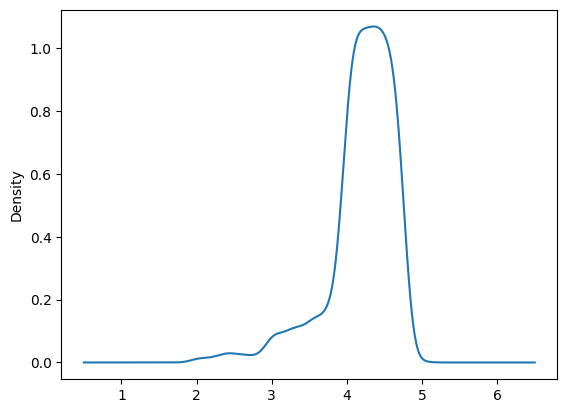

In [13]:
tablets["user_rating"].plot(kind='kde')    # this kind of distribution is expected for ratings.

-0.130566715726082
-0.756929271043913


<Axes: ylabel='Density'>

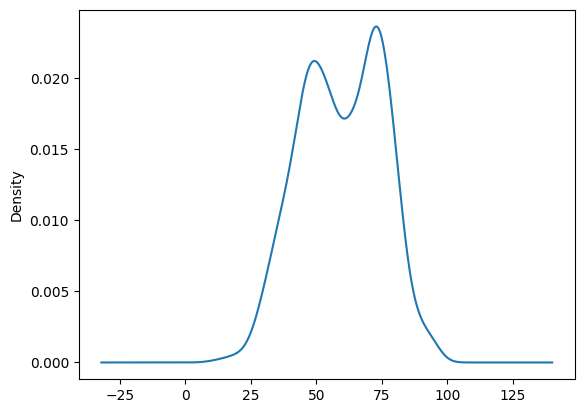

In [14]:
print(tablets["spec_score"].skew())
print(tablets["spec_score"].kurt())
tablets["spec_score"].plot(kind='kde')

# since kurtosis is kind of low, it seems like a uniform distribution

## Cleaning : Completness Issues

In [15]:
# lets start by dropping dupes and null rows.
tablets.duplicated(subset=('name')).sum()

65

In [16]:
tablets[tablets['name'] == 'Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi + 128GB)']

,name,price,spec_score,user_rating,connectivity,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,other
246,Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi ...,17489,65.0,4.75,NaN,"Helio P22T, Octa Core, 2 GHz Processor","4 GB RAM, 128 GB inbuilt",5000 mAh Battery,"10.3 inches, 1920 x 1200 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 256 GB",NaN,NaN,https://cdn1.smartprix.com/rx-i3PSt8PEa-w280-h...,Wi-Fi
309,Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi ...,14999,65.0,4.75,NaN,"Helio P22T, Octa Core, 2 GHz Processor","4 GB RAM, 128 GB inbuilt",5000 mAh Battery,"10.3 inches, 1920 x 1200 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 256 GB",NaN,NaN,https://cdn1.smartprix.com/rx-i3PSt8PEa-w280-h...,Wi-Fi


In [17]:
avg = (17489+14999)/2
avg

16244.0

In [18]:
tablets.drop_duplicates(subset=('name'), inplace = True)

In [19]:
update_idx = tablets[tablets['name'] == 'Lenovo Tab M10 FHD Plus 2nd Gen Tablet (Wi-Fi + 128GB)'].index
tablets.loc[update_idx,"price"] = avg

In [20]:
kindle_idx = tablets[tablets["name"].apply(lambda x: True if (("kindle" in (x.lower())) & ("fire" not in (x.lower()))) else False)].index

In [21]:
tablets = tablets.drop(kindle_idx, axis = 0)

In [22]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1542 entries, 0 to 1628
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1542 non-null   object 
 1   price         1542 non-null   object 
 2   spec_score    1538 non-null   float64
 3   user_rating   1538 non-null   float64
 4   connectivity  1282 non-null   object 
 5   cpu           1503 non-null   object 
 6   ram           1530 non-null   object 
 7   battery       1356 non-null   object 
 8   display       1535 non-null   object 
 9   camera        1539 non-null   object 
 10  expandable    1169 non-null   object 
 11  os            447 non-null    object 
 12  fm_radio      94 non-null     object 
 13  img           1542 non-null   object 
 14  other         1532 non-null   object 
dtypes: float64(2), object(13)
memory usage: 192.8+ KB


In [23]:
tablets["spec_score"].value_counts().index

Index([49.0, 72.0, 73.0, 51.0, 74.0, 54.0, 55.0, 75.0, 77.0, 71.0, 62.0, 46.0,
       69.0, 47.0, 48.0, 44.0, 76.0, 58.0, 70.0, 42.0, 78.0, 81.0, 57.0, 67.0,
       45.0, 52.0, 64.0, 61.0, 66.0, 50.0, 68.0, 63.0, 56.0, 65.0, 53.0, 37.0,
       40.0, 79.0, 43.0, 80.0, 39.0, 59.0, 35.0, 83.0, 82.0, 41.0, 30.0, 36.0,
       38.0, 60.0, 84.0, 34.0, 33.0, 87.0, 32.0, 31.0, 88.0, 27.0, 90.0, 86.0,
       94.0, 95.0, 93.0, 26.0, 28.0, 25.0, 91.0, 89.0, 92.0, 97.0, 17.0, 18.0,
       14.0],
      dtype='float64', name='spec_score')

<Axes: >

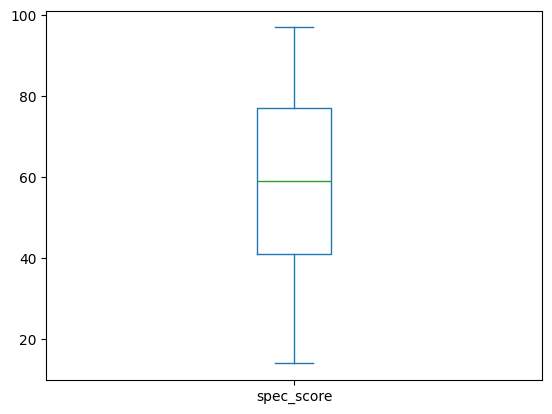

In [24]:
tablets["spec_score"].value_counts().index.to_series().plot(kind="box")

In [25]:
tablets["user_rating"].value_counts().index

Index([ 4.0, 4.15, 4.25, 4.45,  4.5,  4.4,  4.6,  4.3, 4.35, 4.05,  4.1, 4.55,
        4.2, 4.65,  4.7, 4.75, 3.95,  3.9,  3.8, 3.75, 3.55,  3.0, 3.85,  3.6,
        3.3,  3.7,  3.5, 3.15, 3.65, 3.25,  3.4, 3.05, 3.35,  3.2, 3.45,  3.1,
       2.45, 2.95,  2.6,  2.0, 2.75,  2.4,  2.5, 2.35, 2.25,  2.1,  2.9, 2.85,
       2.65,  2.7,  2.3, 2.15],
      dtype='float64', name='user_rating')

<Axes: >

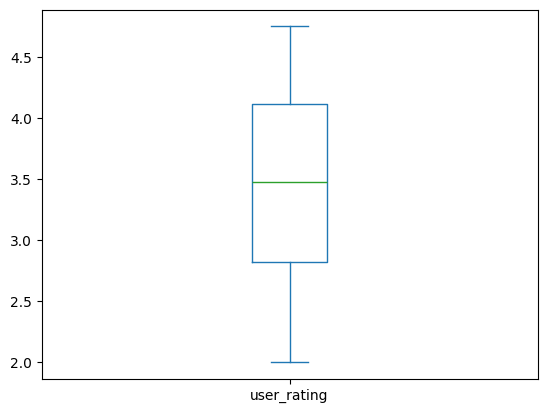

In [26]:
tablets["user_rating"].value_counts().index.to_series().plot(kind="box")

In [27]:
# we will return in the end to impute these values using chained imputation (or iterative imputation)

In [28]:
tablets["connectivity"].unique()

array([nan, 'Single Sim', 'Dual Sim', 'No Sim Supported'], dtype=object)

In [29]:
tablets["other"].unique()   # by the design of web scraping, most of the connectivity values lie in 'other'

array(['3G, 4G, 5G, Wi-Fi', 'Wi-Fi', '3G, 4G, 5G, VoLTE, Wi-Fi',
       '3G, 4G, VoLTE, Wi-Fi', '3G, 4G, 5G, Wi-Fi, NFC', '3G, Wi-Fi',
       '3G, 4G, Wi-Fi', '3G, 4G, 5G, VoLTE, Wi-Fi, NFC',
       '3G, 4G, Wi-Fi, HDMI', '3G, Wi-Fi, HDMI', '3G, 4G, Wi-Fi, NFC',
       'Wi-Fi, HDMI', '3G, 4G, Wi-Fi, HDMI, NFC', 'Wi-Fi, HDMI, NFC',
       'Wi-Fi, IR Blaster', '3G, 4G, Wi-Fi, IR Blaster', 'Wi-Fi, NFC',
       'VoLTE, Wi-Fi', '3G, VoLTE, Wi-Fi', nan,
       '3G, 4G, VoLTE, Wi-Fi, HDMI', '3G, Wi-Fi, NFC', '4G, Wi-Fi'],
      dtype=object)

In [30]:
tablets.rename({
    'connectivity' : 'sim',
    'other' : 'connectivity'
}, axis = 1, inplace = True)

In [31]:
tablets[tablets['sim'].isna()]

# upon closer look, sim column is not useful since we already have network information in connectivity column. Single or Dual Sim is almost irrelevant.
# we can change this column to: has sim or doesnt have sim

,name,price,spec_score,user_rating,sim,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity
0,Samsung Galaxy Tab A9 Plus Tablet (5G+ 8GB RAM...,17905,76.0,4.75,NaN,"Snapdragon 695, Octa Core, 2.2 GHz Processor","8 GB RAM, 128 GB inbuilt",7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,NaN,https://cdn1.smartprix.com/rx-icHlvG2Xk-w280-h...,"3G, 4G, 5G, Wi-Fi"
1,Samsung Galaxy Tab S9 FE Plus 2023 (Wi-Fi Only...,32628,78.0,4.75,NaN,"Exynos 1380, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",10090 mAh Battery with 45W Fast Charging,"12.4 inches, 1600 x 2560 px, 120 Hz Display",8 MP + 8 MP Dual Rear & 12 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,NaN,https://cdn1.smartprix.com/rx-iA0C7Qr5k-w280-h...,Wi-Fi
4,Samsung Galaxy Tab S9 FE (Wi-Fi Only),26280,74.0,4.35,NaN,"Exynos 1380, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",8000 mAh Battery with 45W Fast Charging,"10.9 inches, 1440 x 2304 px, 90 Hz Display",8 MP Rear & 12 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,NaN,https://cdn1.smartprix.com/rx-iVBmqu3Tx-w280-h...,Wi-Fi
6,Samsung Galaxy Tab A10,11990,53.0,4.60,NaN,Octa Core Processor,"4 GB RAM, 128 GB inbuilt",7050 mAh Battery with 25W Fast Charging,"8.8 inches, 800 x 1340 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v15,NaN,https://cdn1.smartprix.com/rx-iEBjMxCiv-w280-h...,Wi-Fi
7,Samsung Galaxy Tab A9 Plus Tablet (Wi-Fi+8GB R...,20999,70.0,4.15,NaN,"Snapdragon 695, Octa Core, 2.2 GHz Processor","8 GB RAM, 128 GB inbuilt",7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,NaN,https://cdn1.smartprix.com/rx-igridT4qW-w280-h...,Wi-Fi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1517,Doogee U10 Tablet,23999,39.0,4.60,NaN,"Rockchip RK3562, Quad Core, 2 GHz Processor",9 GB RAM,5060 mAh Battery,10.1 inches Display,8 MP Rear & 5 MP Front Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-ieAczWNqz-w280-h...,Wi-Fi
1527,Swipe Slate 3 Tablet (Wi-Fi + 32GB),8999,55.0,4.55,NaN,"Tiger T310, Quad Core, 2 GHz Processor","3 GB RAM, 32 GB inbuilt",6000 mAh Battery,"10.1 inches, 1200 x 800 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 128 GB",NaN,NaN,https://cdn1.smartprix.com/rx-ikC9VUVc8-w280-h...,Wi-Fi
1528,Swipe Slate 3 Tablet (Wi-Fi + 64GB),10999,57.0,4.10,NaN,"Tiger T310, Quad Core, 2 GHz Processor","4 GB RAM, 64 GB inbuilt",6000 mAh Battery,"10.1 inches, 1200 x 800 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 128 GB",NaN,NaN,https://cdn1.smartprix.com/rx-iep1xDxeZ-w280-h...,Wi-Fi
1552,Swipe MTV Slash 3X Tablet (WiFi+3G+8GB),4439,33.0,3.80,NaN,NaN,8 GB inbuilt,NaN,"7 inches, 1024 x 600 px Display",0.3 MP Front Camera & No Rear Camera,"Memory Card Supported, upto 32 GB",Android v4.4.2 (KitKat),NaN,https://cdn1.smartprix.com/rx-i05Ys4iqN-w280-h...,"3G, Wi-Fi"


In [32]:
# Ideally, we can always look up these missing values for sim availability in such projects, but since that is a lot of manual work,
# we will skip that part and smoothen out out column a little by assumptious filling.we are setting sim as 0 if there are missing values
# in both columns or is there is No sim supported in sim column or if there is no "3/4/5G" in connectivity column.

def change_sim(row):
    if (not(pd.isna(row['sim']))) and (row['sim'] != 'No Sim Supported'):
        return 1
    elif (pd.isna(row['sim'])) and (pd.isna(row['connectivity'])):
        return 0
    elif (pd.isna(row['sim'])) and ((bool(re.search(r'[3-5]G', row['connectivity']))) or (bool(re.search(r'volte', row['connectivity'], re.IGNORECASE)))):
        return 1
    else:
        return 0

In [33]:
tablets['has_sim'] = tablets.apply(lambda x: change_sim(x), axis = 1)

In [34]:
tablets.drop(["sim"], axis = 1, inplace = True)

In [35]:
tablets[(tablets["connectivity"].isna())]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
879,iKall N18 Smart Tablet (6GB RAM + 128GB),9519,NaN,4.25,NaN,"6.0 GB RAM, 128.0 GB ROM",Battery: 6000 mAh Lithium Polymer batterie,25.4 cm (10 inch) Full HD Display,13.0 MP Primary Camera & 8 MP Front,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-inhDuo8jq-w280-h...,NaN,0
973,DOMO Slate SS5 Tablet,4999,63.0,4.30,NaN,"2 GB RAM, 32 GB ROM",Battery: 3000 mAh Rechargeable Polymer Battery,17.78 cm (7 inch) Display,5 MP Primary Camera & 2 MP Front,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-iuY8sTXtF-w280-h...,NaN,0
992,DOMO Slate SL31 Tablet,6490,49.0,4.30,"Helio MT6582, Quad Core, 1.3 GHz Processor","2 GB RAM, 32 GB inbuilt",3000 mAh Battery,"10.1 inches, 1080 x 800 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 128 GB",NaN,NaN,https://cdn1.smartprix.com/rx-i2ycZYGTF-w280-h...,NaN,1
993,DOMO Slate SL30 Tablet,4490,46.0,4.00,"Helio MT6582, Quad Core, 1.3 GHz Processor","1 GB RAM, 16 GB inbuilt",3000 mAh Battery,"10.1 inches, 1280 x 800 px Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 128 GB",NaN,NaN,https://cdn1.smartprix.com/rx-iYFb5Pmo5-w280-h...,NaN,1
1315,Micromax Funbook P256 Tablet (WiFi+4GB),4299,30.0,3.15,"Single Core, 1.2 GHz Processor","512 MB RAM, 4 GB inbuilt",3000 mAh Battery,"7 inches, 480 x 800 px Display",3 MP Rear & 1.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-iO4PF453r-w280-h...,NaN,0
1455,Microsoft Surface Pro 4 (6th Gen Ci5/ 8GB/ 256...,96890,55.0,2.70,Single Core Processor,"8 GB RAM, 256 GB inbuilt",NaN,"12.3 inches, 2736 x 1824 px Display",No Rear Camera,NaN,v10,No FM Radio,https://cdn1.smartprix.com/rx-iXTwu5yf3-w280-h...,NaN,1
1458,Microsoft Surface Pro 3 12.0 Tablet (4th Gen C...,105500,NaN,3.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-ibx2PiQbV-w280-h...,NaN,0
1459,Microsoft Surface Pro 3 12.0 Tablet (4th Gen C...,79500,NaN,3.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-iddV7mYSy-w280-h...,NaN,0
1460,Microsoft Surface Pro 2 10.6 Tablet (4th Gen C...,108900,NaN,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-ilJqrLvpu-w280-h...,NaN,0
1563,Swipe Halo Value 8 Tablet (WiFi+2G+8GB),6799,34.0,3.75,NaN,"512 MB RAM, 8 GB inbuilt",4000 mAh Battery,"8 inches, 600 x 800 px Display",2 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v4.0 (ICS),NaN,https://cdn1.smartprix.com/rx-iv2t3Ql7e-w280-h...,NaN,1


In [36]:
tablets[(pd.isna(tablets['cpu'])) & (pd.isna(tablets['ram'])) & (pd.isna(tablets['battery'])) & (pd.isna(tablets['display'])) & (pd.isna(tablets['connectivity']))]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
1458,Microsoft Surface Pro 3 12.0 Tablet (4th Gen C...,105500,NaN,3.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-ibx2PiQbV-w280-h...,NaN,0
1459,Microsoft Surface Pro 3 12.0 Tablet (4th Gen C...,79500,NaN,3.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-iddV7mYSy-w280-h...,NaN,0
1460,Microsoft Surface Pro 2 10.6 Tablet (4th Gen C...,108900,NaN,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-ilJqrLvpu-w280-h...,NaN,0


In [37]:
tablets.dropna(subset = ('cpu', 'ram', 'battery', 'display', 'connectivity'),how = 'all', inplace=True)

In [38]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1539 entries, 0 to 1628
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1539 non-null   object 
 1   price         1539 non-null   object 
 2   spec_score    1538 non-null   float64
 3   user_rating   1535 non-null   float64
 4   cpu           1503 non-null   object 
 5   ram           1530 non-null   object 
 6   battery       1356 non-null   object 
 7   display       1535 non-null   object 
 8   camera        1539 non-null   object 
 9   expandable    1169 non-null   object 
 10  os            447 non-null    object 
 11  fm_radio      94 non-null     object 
 12  img           1539 non-null   object 
 13  connectivity  1532 non-null   object 
 14  has_sim       1539 non-null   int64  
dtypes: float64(2), int64(1), object(12)
memory usage: 192.4+ KB


In [39]:
tablets['cpu'].apply(lambda x: x.replace('\u2009','') if isinstance(x,str) else x).unique()

array(['Snapdragon 695, Octa Core, 2.2GHz Processor',
       'Exynos 1380, Octa Core, 2.4GHz Processor',
       'Dimensity 9400 Plus, Octa Core Processor',
       'Exynos 1580, Octa Core, 2.9GHz Processor', 'Octa Core Processor',
       'Helio G99, Octa Core, 2.2GHz Processor',
       'Snapdragon 8 Gen1, Octa Core, 3GHz Processor',
       'Dimensity 9300 Plus, Octa Core, 3.25GHz Processor',
       'Snapdragon 8 Gen2, Octa Core, 3.2GHz Processor',
       'Helio P22T, Octa Core, 2.4GHz Processor',
       'Snapdragon 662 , Octa Core, 2GHz Processor',
       'Dimensity 9300 Plus, Octa Core Processor',
       'Snapdragon 7s Gen3, Octa Core, 2.5GHz Processor',
       'Snapdragon 720G, Octa Core, 2.3GHz Processor',
       'Tiger T618, Octa Core, 2GHz Processor',
       'Kompanio 900T, Octa Core, 2.6GHz Processor',
       'Snapdragon 750G , Octa Core, 2.2GHz Processor',
       'Snapdragon 865+, Octa Core, 3.09GHz Processor',
       'Exynos 7904, Octa Core, 1.8GHz Processor',
       'Exynos  79

In [40]:
tablets[tablets['cpu'].isna()]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
347,Lenovo Idea Tab A3000 Tablet,14500,40.0,4.50,NaN,16 GB inbuilt,3500 mAh Battery,"7 inches, 1024 x 600 px Display",5 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-ivMqRERpp-w280-h...,"3G, Wi-Fi",1
529,Apple iPad Mini 2019 (WiFi + 256GB),47900,50.0,4.65,NaN,256 GB inbuilt,NaN,"7.9 inches, 2048 x 1536 px Display",8 MP Rear & 7 MP Front Camera,NaN,iOS v12,No FM Radio,https://cdn1.smartprix.com/rx-ipkHYQWPK-w280-h...,Wi-Fi,0
783,Huawei MatePad Pro 13.2 2025,59990,70.0,4.15,NaN,"12 GB RAM, 256 GB inbuilt",10100 mAh Battery with 100W Fast Charging,"13.2 inches, 2880 x 1920 px, 144 Hz Display",50 MP + 8 MP Dual Rear & 16 MP Front Camera,NaN,Harmony OS v4.3,No FM Radio,https://cdn1.smartprix.com/rx-iAQqRpf8T-w280-h...,Wi-Fi,0
785,Huawei MatePad SE 11,24990,54.0,4.10,NaN,"4 GB RAM, 64 GB inbuilt",7700 mAh Battery with Fast Charging,"11 inches, 1200 x 1920 px Display",8 MP Rear & 5 MP Front Camera,Memory Card Supported,HarmonyOS v2.0,NaN,https://cdn1.smartprix.com/rx-i7x8PuQ2K-w280-h...,Wi-Fi,0
863,iKall N11 Plus Tablet,3349,49.0,4.00,NaN,"2 GB RAM, 16 GB inbuilt",3000 mAh Battery,"7 inches, 1024 x 600 px Display",2 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v8 (Oreo),NaN,https://cdn1.smartprix.com/rx-iBaQKKVmH-w280-h...,"3G, 4G, VoLTE, Wi-Fi",1
866,iKall N7 Pro Tablet (Wi-Fi Only),3399,39.0,4.00,NaN,"2 GB RAM, 16 GB inbuilt",3000 mAh Battery,"7 inches, 580 x 980 px Display",2 MP Rear & 0.3 MP Front Camera,Memory Card Supported,Android v6.0 (Marshmallow),NaN,https://cdn1.smartprix.com/rx-iaB6ptFGy-w280-h...,Wi-Fi,0
869,iKall N11 New Tablet (Wi-Fi Only),3307,49.0,4.50,NaN,"2 GB RAM, 16 GB inbuilt",3000 mAh Battery,"7 inches, 1024 x 600 px Display",2 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v6.0 (Marshmallow),NaN,https://cdn1.smartprix.com/rx-i1xViMXDh-w280-h...,"3G, 4G, VoLTE, Wi-Fi",1
874,iKall N12 Tablet,7099,51.0,4.45,NaN,"4 GB RAM, 32 GB inbuilt",3000 mAh Battery,"7 inches, 1024 x 600 px Display",5 MP Rear & 2 MP Front Camera,NaN,Android v6.0 (Marshmallow),No FM Radio,https://cdn1.smartprix.com/rx-i5k4Z0rZw-w280-h...,"3G, 4G, VoLTE, Wi-Fi",1
879,iKall N18 Smart Tablet (6GB RAM + 128GB),9519,NaN,4.25,NaN,"6.0 GB RAM, 128.0 GB ROM",Battery: 6000 mAh Lithium Polymer batterie,25.4 cm (10 inch) Full HD Display,13.0 MP Primary Camera & 8 MP Front,NaN,NaN,NaN,https://cdn1.smartprix.com/rx-inhDuo8jq-w280-h...,NaN,0
890,iKall N2 Pro New Tablet,3194,37.0,4.60,NaN,"512 MB RAM, 4 GB inbuilt",2800 mAh Battery,"7 inches, 1024 x 600 px Display",2 MP Rear & 0.3 MP Front Camera,NaN,Android v6.0 (Marshmallow),NaN,https://cdn1.smartprix.com/rx-iAVQr1YfR-w280-h...,"3G, 4G, Wi-Fi",1


In [41]:
cpu_missing = tablets[tablets['cpu'].isna()]

In [42]:
tablets[(tablets['name']=='Lenovo IdeaTab A3000') | (tablets['name']=='Lenovo Idea Tab A3000 Tablet')]

# same tablets

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
347,Lenovo Idea Tab A3000 Tablet,14500,40.0,4.50,NaN,16 GB inbuilt,3500 mAh Battery,"7 inches, 1024 x 600 px Display",5 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-ivMqRERpp-w280-h...,"3G, Wi-Fi",1
408,Lenovo IdeaTab A3000,7999,49.0,4.25,"Quad Core, 1.2 GHz Processor","1 GB RAM, 16 GB inbuilt",3500 mAh Battery,"7 inches, 600 x 1024 px Display",5 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-iaBI421vU-w280-h...,"3G, Wi-Fi",1


In [43]:
tablets.drop([347], axis = 0, inplace=True)

In [44]:
tablets[(tablets['name']=='Lenovo IdeaTab A3000') | (tablets['name']=='Lenovo Idea Tab A3000 Tablet')]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
408,Lenovo IdeaTab A3000,7999,49.0,4.25,"Quad Core, 1.2 GHz Processor","1 GB RAM, 16 GB inbuilt",3500 mAh Battery,"7 inches, 600 x 1024 px Display",5 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-iaBI421vU-w280-h...,"3G, Wi-Fi",1


In [45]:
# some analysis..

In [46]:
tablets[tablets['name'].apply(lambda x: True if ('lenovo' in x.lower()) else False)]['cpu'].value_counts()

cpu
Snapdragon 450, Octa Core, 1.8 GHz Processor      15
Snapdragon 870, Octa Core, 3.2 GHz Processor       9
Helio G88, Octa Core, 2 GHz Processor              9
Quad Core, 1.3 GHz Processor                       8
Helio P22T, Octa Core, 2 GHz Processor             8
                                                  ..
Snapdragon 410, Quad Core, 1.2 GHz Processor       1
Snapdragon MSM8953, Octa Core, 2 GHz Processor     1
Intel x5-Z8550, Quad Core, 2.4 GHz Processor       1
x5Z8550, Quad Core, 2.4 GHz Processor              1
Single Core, 1.8 GHz Processor                     1
Name: count, Length: 83, dtype: int64

In [47]:
tablets[tablets['name'].apply(lambda x: True if ('lenovo' in x.lower()) else False)]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
205,Lenovo Xiaoxin Pad Pro 12.7,18499,81.0,4.60,"Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",10200 mAh Battery with 20W Fast Charging,"12.7 inches, 2944 x 1840 px, 144 Hz Display",8 MP Rear & 13 MP Front Camera,"Memory Card Supported, upto 1 TB",NaN,NaN,https://cdn1.smartprix.com/rx-isH9pULQB-w280-h...,"3G, 4G, 5G, VoLTE, Wi-Fi",1
206,Lenovo Idea Tab Pro,27999,77.0,4.50,"Dimensity 8300, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",10200 mAh Battery with 45W Fast Charging,"12.7 inches, 2944 x 1840 px, 144 Hz Display",13 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",NaN,NaN,https://cdn1.smartprix.com/rx-ipO7ZFMi2-w280-h...,Wi-Fi,0
207,Lenovo Tab M11 (4GB RAM + 128GB + LTE),12499,75.0,4.55,"Helio G88, Octa Core, 2 GHz Processor","4 GB RAM, 128 GB inbuilt",7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",13 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",NaN,NaN,https://cdn1.smartprix.com/rx-i5OzltYZY-w280-h...,"3G, 4G, Wi-Fi",1
208,Lenovo Idea Tab Pro (12GB RAM + 256GB),30999,79.0,4.60,"Dimensity 8300, Octa Core, 3.35 GHz Processor","12 GB RAM, 256 GB inbuilt",10200 mAh Battery with 45W Fast Charging,"12.7 inches, 2944 x 1840 px, 144 Hz Display",13 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",NaN,NaN,https://cdn1.smartprix.com/rx-ipO7ZFMi2-w280-h...,Wi-Fi,0
209,Lenovo Xiaoxin Pad Pro 12.7 (8GB RAM + 256GB),20499,82.0,4.70,"Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",10200 mAh Battery with 20W Fast Charging,"12.7 inches, 2944 x 1840 px, 144 Hz Display",8 MP Rear & 13 MP Front Camera,"Memory Card Supported, upto 1 TB",NaN,NaN,https://cdn1.smartprix.com/rx-iBADXWSjw-w280-h...,"3G, 4G, 5G, VoLTE, Wi-Fi",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,Lenovo ThinkPad Tablet 1838RY1 WiFi+3G (32GB),18849,48.0,3.85,"Dual Core, 1 GHz Processor",32 GB inbuilt,NaN,"10.1 inches, 1280 x 800 px Display",5 MP Rear & 2 MP Front Camera,Memory Card Supported,Android v3.1 (Honeycomb),NaN,https://cdn1.smartprix.com/rx-if0wtz0ow-w280-h...,"3G, Wi-Fi, HDMI",1
415,Lenovo IdeaPad A1,11386,40.0,3.95,"Single Core, 1 GHz Processor","512 MB RAM, 16 GB inbuilt",NaN,"7 inches, 600 x 1024 px Display",3.15 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v2.3 (Gingerbread),NaN,https://cdn1.smartprix.com/rx-ivE37sDjb-w280-h...,Wi-Fi,0
416,Lenovo IdeaPad K1 (WiFi+3G+32GB),30000,49.0,2.95,"Dual Core, 1 GHz Processor",32 GB inbuilt,NaN,"10.1 inches, 1280 x 800 px Display",5 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v3.1 (Honeycomb),NaN,https://cdn1.smartprix.com/rx-iATCGZYYD-w280-h...,"3G, Wi-Fi",1
417,Lenovo IdeaPad A2107 (WiFi+16GB),9477,40.0,3.30,"Single Core, 1 GHz Processor",16 GB inbuilt,3550 mAh Battery,"7 inches, 1024 x 600 px Display",2 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-iV1V4DcpC-w280-h...,Wi-Fi,1


In [48]:
cpu_missing[cpu_missing['name'].apply(lambda x: True if ('lenovo' in x.lower()) else False)]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
347,Lenovo Idea Tab A3000 Tablet,14500,40.0,4.5,NaN,16 GB inbuilt,3500 mAh Battery,"7 inches, 1024 x 600 px Display",5 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,https://cdn1.smartprix.com/rx-ivMqRERpp-w280-h...,"3G, Wi-Fi",1


In [49]:
tablets[tablets['display'].isna()]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
1041,Acer Aspire P3-171 Hybrid Ultrabook Tablet (Wi...,61821,26.0,4.60,Single Core Processor,NaN,NaN,NaN,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-i5XZk8KVA-w280-h...,Wi-Fi,1
1279,Lava Xtron Z704 Tablet,2499,17.0,3.35,"Quad Core, 1.3 GHz Processor",NaN,NaN,NaN,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iM3S0WX8S-w280-h...,Wi-Fi,1
1407,Bsnl Penta T-PAD IS701D,3875,28.0,4.65,"Dual Core, 1.3 GHz Processor","512 MB RAM, 4 GB inbuilt",NaN,NaN,2 MP Rear Camera,Memory Card Supported,Android v4.2 (Jelly Bean),NaN,https://cdn1.smartprix.com/rx-iONF4CaSq-w280-h...,"3G, Wi-Fi",1
1557,Swipe Fablet F1 (WiFi+3G+4GB),5499,14.0,3.55,"6575, Single Core, 1 GHz Processor",NaN,NaN,NaN,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iKBply81W-w280-h...,Wi-Fi,1


In [50]:
tablets[((pd.isna(tablets['display'])) & (pd.isna(tablets['battery']))) | ((pd.isna(tablets['ram'])) & (pd.isna(tablets['battery'])))]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim
1041,Acer Aspire P3-171 Hybrid Ultrabook Tablet (Wi...,61821,26.0,4.60,Single Core Processor,NaN,NaN,NaN,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-i5XZk8KVA-w280-h...,Wi-Fi,1
1160,iBall Slide 3G 8072 Tab (WiFi+3G+4GB),10999,35.0,3.40,"Dual Core, 1 GHz Processor",NaN,NaN,"8 inches, 768 x 1024 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB",Android v4.1 (Jelly Bean),No FM Radio,https://cdn1.smartprix.com/rx-igk31GKkX-w280-h...,"3G, Wi-Fi",1
1165,iBall Performance Series Slide 3G 9728,13999,35.0,3.05,"Dual Core, 1 GHz Processor",NaN,NaN,"9.69 inches, 768 x 1024 px Display",5 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v4.1 (Jelly Bean),NaN,https://cdn1.smartprix.com/rx-idoEdUEJr-w280-h...,"3G, Wi-Fi",1
1279,Lava Xtron Z704 Tablet,2499,17.0,3.35,"Quad Core, 1.3 GHz Processor",NaN,NaN,NaN,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iM3S0WX8S-w280-h...,Wi-Fi,1
1358,Asus ROG Flow Z13 Gaming Tablet,44990,35.0,4.15,Core i9,NaN,NaN,"13.4 inches, 1920 x 1080 px, 120 Hz Display",No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iSmEQ7jcX-w280-h...,Wi-Fi,0
1407,Bsnl Penta T-PAD IS701D,3875,28.0,4.65,"Dual Core, 1.3 GHz Processor","512 MB RAM, 4 GB inbuilt",NaN,NaN,2 MP Rear Camera,Memory Card Supported,Android v4.2 (Jelly Bean),NaN,https://cdn1.smartprix.com/rx-iONF4CaSq-w280-h...,"3G, Wi-Fi",1
1433,Croma XT1177 Tablet,6594,18.0,3.00,Single Core Processor,NaN,NaN,10.1 inches Display,2 MP Rear & 2 MP Front Camera,Memory Card Supported,Windows 8 v8.1,No FM Radio,https://cdn1.smartprix.com/rx-iy1pRapUe-w280-h...,Wi-Fi,1
1557,Swipe Fablet F1 (WiFi+3G+4GB),5499,14.0,3.55,"6575, Single Core, 1 GHz Processor",NaN,NaN,NaN,No Rear Camera,NaN,NaN,No FM Radio,https://cdn1.smartprix.com/rx-iKBply81W-w280-h...,Wi-Fi,1


In [51]:
# there is nothing much we can do about null values in these columns without losing information, so we will just ignore them.

In [52]:
tablets['expandable'].value_counts()

expandable
Memory Card Supported, upto 32 GB      349
Memory Card Supported, upto 1 TB       158
Memory Card Supported                  137
Memory Card Not Supported              116
Memory Card Supported, upto 64 GB      109
Memory Card Supported, upto 128 GB      94
Memory Card Supported, upto 256 GB      77
Memory Card Supported, upto 512 GB      63
Memory Card (Hybrid), upto 1 TB         23
Memory Card Supported, upto 2 TB         9
Memory Card Supported, upto 1.5 TB       6
Memory Card (Hybrid), upto 512 GB        6
Memory Card (Hybrid)                     6
Memory Card (Hybrid), upto 2 TB          5
Memory Card Supported, upto 400 GB       4
Memory Card (Hybrid), upto 1.5 TB        2
Memory Card (Hybrid), upto 64 GB         2
Memory Card Supported, upto 1.02 TB      1
Memory Card (Hybrid), upto 256 GB        1
Name: count, dtype: int64

In [53]:
pd.isna(tablets['expandable']).sum()

370

In [54]:
tablets['expandable'] = tablets['expandable'].fillna(0)   # just gonna assume missing values mean no memory card available.

In [55]:
tablets['os'].unique()

array(['Android v13', nan, 'Android v15', 'Android v14', 'Android v11',
       'Android v3 (Honeycomb)', 'Android v16', 'Android v12',
       'Android v10', 'Android v8.1 (Oreo)', 'Android v9 (Pie)',
       'Android v9.0 (Pie)', 'Android v8.0 (Oreo)', 'v8.1',
       'Windows 8 v8.1', 'Android v4 (ICS)', 'v8',
       'Android v2.3 (Gingerbread)', 'Windows 8 v8',
       'Android v3.1 (Honeycomb)', 'iPadOS v18.3.1', 'iPadOS v16',
       'iOS v15', 'iPadOS v17.4', 'ipad OS v17.4', 'iPadOS v17',
       'iOS v18.3.1', 'iPadOS v18', 'iOS v14.5', 'iOS v12.1.3', 'iOS v12',
       'iOS v16', 'iOS v14', 'iOS v8.1', 'iPadOS v14', 'iOS v13.4',
       'iOS v12.0', 'iOS v13.1', 'iOS v11.3', 'iOS v9', 'iOS v7.0.4',
       'iOS v6', 'Android v13.1', 'Android v3.0 (Honeycomb)',
       'HarmonyOS v4.3', 'HarmonyOS v4.2', 'Harmony OS v4.0',
       'Harmony OS v3.1', 'Harmony OS v4.3', 'HarmonyOS v3.1',
       'HarmonyOS v2.0', 'Windows v10', 'Android v4.0 (ICS)',
       'Android v8 (Oreo)', 'Android v6.0 

In [56]:
tablets['brand'] = tablets['name'].str.split().str.get(0).str.lower()

In [57]:
tablets['brand'].unique()

array(['samsung', 'xiaomi', 'lenovo', 'apple', 'oneplus', 'motorola',
       'realme', 'honor', 'huawei', 'oppo', 'infinix', 'ikall', 'vivo',
       'poco', 'domo', 'nokia', 'acer', 'iqoo', 'iball', 'amazon', 'new',
       'nubia', 'teclast', 'tcl', 'blackview', 'itel', 'lava', 'micromax',
       'wishtel', 'asus', 'bsnl', 'croma', 'cubot', 'google', 'htc',
       'microsoft', 'datawind', 'blackberry', 'boox', 'b00x', 'doogee',
       'nothing', 'swipe', 'tecno', 'amtrak', 'byond', 'dell', 'fusion5',
       'intex', 'jio'], dtype=object)

In [58]:
tablets[tablets['brand'] == 'new']

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim,brand
1202,New Kindle HD Fire 6,9990,42.0,3.6,"Dual Core, 1.5 GHz Processor","1 GB RAM, 16 GB inbuilt",NaN,"6 inches, 800 x 1280 px Display",2 MP Rear & 0.3 MP Front Camera,Memory Card Not Supported,Android v4.4 (KitKat),NaN,https://cdn1.smartprix.com/rx-ixetlsusK-w280-h...,"Wi-Fi, HDMI",0,new


In [59]:
tablets.loc[1202,'brand'] = 'amazon'

In [60]:
tablets[tablets['brand'] == 'b00x']

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim,brand
1489,B00X Note Air 3C 3C EInk eReader,74990,73.0,4.15,"Octa Core, 2.4 GHz Processor","4 GB RAM, 64 GB inbuilt",3700 mAh Battery,"10.3 inches, 1860 x 2480 px Display",16 MP Rear Camera,Memory Card Supported,Android v12,NaN,https://cdn1.smartprix.com/rx-iHJrqATk5-w280-h...,Wi-Fi,0,b00x


In [61]:
tablets.loc[1489,'brand'] = 'boox'

In [62]:
tablets[tablets['os'].apply(lambda x: True if ((isinstance(x,str)) and ('windows' in x.lower())) else False)]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim,brand
389,"Lenovo Miix 2 10"" Tablet",18999,55.0,3.00,"Quad Core, 1.8 GHz Processor","2 GB RAM, 32 GB inbuilt",NaN,"8 inches, 800 x 1280 px Display",5 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 128 GB",Windows 8 v8.1,NaN,https://cdn1.smartprix.com/rx-i77DQkYU1-w280-h...,"3G, Wi-Fi",0,lenovo
412,Lenovo ThinkPad Tablet 2,35000,57.0,3.85,"Single Core, 1.8 GHz Processor","2 GB RAM, 64 GB inbuilt",NaN,"10.1 inches, 1366 x 768 px Display",8 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 32 GB",Windows 8 v8,NaN,https://cdn1.smartprix.com/rx-iRJPM8qYx-w280-h...,"3G, Wi-Fi, HDMI",1,lenovo
826,Huawei Matebook E 2019,41999,78.0,4.10,"Snapdragon 855, Octa Core, 2.84 GHz Processor","8 GB RAM, 256 GB inbuilt",NaN,"12 inches, 1440 x 2560 px Display",13 MP Rear & 5 MP Front Camera,0,Windows v10,No FM Radio,https://cdn1.smartprix.com/rx-iy2XirRtv-w280-h...,"3G, 4G, Wi-Fi",1,huawei
1030,Acer Iconia W1-811 Tablet,9299,51.0,3.60,"Intel Z3735F, Quad Core, 1.83 GHz Processor","2 GB RAM, 32 GB inbuilt",4600 mAh Battery,"8 inches, 768 x 1280 px Display",2 MP Rear & 2 MP Front Camera,0,Windows 8 v8,NaN,https://cdn1.smartprix.com/rx-imRlzN0QQ-w280-h...,"3G, Wi-Fi",1,acer
1031,Acer Iconia Tab 8W (32GB),6999,42.0,3.60,"Z3735G, Quad Core, 1.33 GHz Processor","1 GB RAM, 32 GB inbuilt",4600 mAh Battery,"8 inches, 1280 x 800 px Display",2 MP Rear Camera,0,Windows 8 v8.1,NaN,https://cdn1.smartprix.com/rx-im7iFqwYp-w280-h...,Wi-Fi,1,acer
1045,Acer Aspire P3-171 Hybrid Ultrabook Tablet (Wi...,39000,53.0,NaN,"Intel, Dual Core, 1.4 GHz Processor","2 GB RAM, 60 GB inbuilt",5280 mAh Battery,"11.6 inches, 768 x 1366 px Display",5 MP Rear & 0.3 MP Front Camera,0,Windows 8 v8,NaN,https://cdn1.smartprix.com/rx-iS4TLZVUx-w280-h...,"Wi-Fi, HDMI",0,acer
1374,ASUS VivoTab Note 8 M80T (32GB),34218,51.0,4.65,"Quad Core, 1.86 GHz Processor","2 GB RAM, 32 GB inbuilt",3950 mAh Battery,"8 inches, 800 x 1280 px Display",5 MP Rear & 1.3 MP Front Camera,0,Windows 8 v8.1,NaN,https://cdn1.smartprix.com/rx-i3MJC9SS5-w280-h...,Wi-Fi,0,asus
1384,Asus VivoTab RT TF600T (32GB),58000,58.0,4.45,"Dual Core, 1.8 GHz Processor","2 GB RAM, 64 GB inbuilt",7500 mAh Battery,"11.6 inches, 768 x 1336 px Display",8 MP Rear & 2 MP Front Camera,0,Windows 8 v8,NaN,https://cdn1.smartprix.com/rx-iEZg2IeUJ-w280-h...,"Wi-Fi, HDMI, NFC",0,asus
1386,Asus VivoTab ME400CL-1A057W Smart Tablet (WiFi...,41999,54.0,4.55,Single Core Processor,"2 GB RAM, 64 GB inbuilt",NaN,"11.6 inches, 1366 x 768 px Display",8 MP Rear & 2 MP Front Camera,Memory Card Supported,Windows 8 v8,NaN,https://cdn1.smartprix.com/rx-iEQELxzoQ-w280-h...,"Wi-Fi, HDMI, NFC",0,asus
1433,Croma XT1177 Tablet,6594,18.0,3.00,Single Core Processor,NaN,NaN,10.1 inches Display,2 MP Rear & 2 MP Front Camera,Memory Card Supported,Windows 8 v8.1,No FM Radio,https://cdn1.smartprix.com/rx-iy1pRapUe-w280-h...,Wi-Fi,1,croma


<Axes: title={'center': 'missing values brand wise'}, xlabel='brand'>

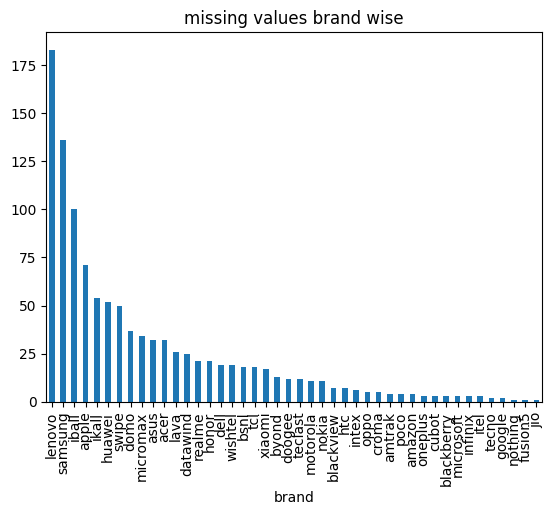

In [63]:
tablets[pd.isna(tablets['os'])].loc[:,'brand'].value_counts().plot(kind='bar', title="missing values brand wise")

<Axes: title={'center': 'brands with most OS other than android or ios'}, xlabel='brand'>

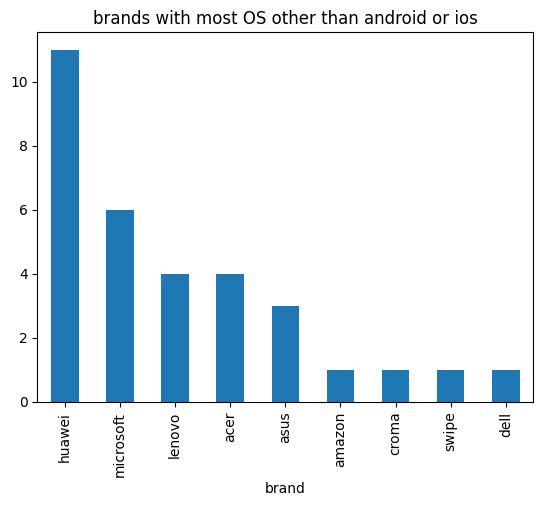

In [64]:
tablets[tablets['os'].apply(lambda x: True if (not(pd.isna(x))) and ('android' not in x.lower()) and ('ios' not in x.lower()) and ('ipados' not in x.lower() and ('ipad os' not in x.lower())) else False)].loc[:,'brand'].value_counts().plot(kind='bar', title="brands with most OS other than android or ios")

In [65]:
tablets[tablets['brand'] == 'apple'].loc[:,'os'].unique()

array(['iPadOS v18.3.1', 'iPadOS v16', 'iOS v15', 'iPadOS v17.4',
       'ipad OS v17.4', 'iPadOS v17', 'iOS v18.3.1', 'iPadOS v18',
       'iOS v14.5', 'iOS v12.1.3', 'iOS v12', 'iOS v16', 'iOS v14', nan,
       'iOS v8.1', 'iPadOS v14', 'iOS v13.4', 'iOS v12.0', 'iOS v13.1',
       'iOS v11.3', 'iOS v9', 'iOS v7.0.4', 'iOS v6'], dtype=object)

In [66]:
tablets[tablets['os'].apply(lambda x: True if (not(pd.isna(x))) and ('android' not in x.lower()) and ('ios' not in x.lower()) and ('ipados' not in x.lower() and ('ipad os' not in x.lower())) else False)]

,name,price,spec_score,user_rating,cpu,ram,battery,display,camera,expandable,os,fm_radio,img,connectivity,has_sim,brand
384,Lenovo Thinkpad 8 Tablet (WiFi+2G+64GB),23999,47.0,3.65,Intel Z3770,64 GB inbuilt,NaN,"8.3 inches, 1920 x 1200 px Display",2 MP Front Camera & No Rear Camera,"Memory Card Supported, upto 128 GB",v8.1,NaN,https://cdn1.smartprix.com/rx-iPel40i3J-w280-h...,Wi-Fi,0,lenovo
389,"Lenovo Miix 2 10"" Tablet",18999,55.0,3.00,"Quad Core, 1.8 GHz Processor","2 GB RAM, 32 GB inbuilt",NaN,"8 inches, 800 x 1280 px Display",5 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 128 GB",Windows 8 v8.1,NaN,https://cdn1.smartprix.com/rx-i77DQkYU1-w280-h...,"3G, Wi-Fi",0,lenovo
399,"Lenovo Miix 2 8"" Tablet",9999,47.0,4.10,Quad Core Processor,"2 GB RAM, 32 GB inbuilt",NaN,"8 inches, 800 x 1280 px Display",5 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 32 GB",v8,NaN,https://cdn1.smartprix.com/rx-iYpuewbF9-w280-h...,"3G, Wi-Fi",0,lenovo
412,Lenovo ThinkPad Tablet 2,35000,57.0,3.85,"Single Core, 1.8 GHz Processor","2 GB RAM, 64 GB inbuilt",NaN,"10.1 inches, 1366 x 768 px Display",8 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 32 GB",Windows 8 v8,NaN,https://cdn1.smartprix.com/rx-iRJPM8qYx-w280-h...,"3G, Wi-Fi, HDMI",1,lenovo
779,Huawei MatePad Pro 12.2 (2025),81990,81.0,4.50,"Kirin 9000S, Octa Core, 2.62 GHz Processor","12 GB RAM, 256 GB inbuilt",10100 mAh Battery with 100W Fast Charging,"12.2 inches, 2800 x 1840 px Display",50 MP + 8 MP Dual Rear & 8 MP Front Camera,0,HarmonyOS v4.3,NaN,https://cdn1.smartprix.com/rx-iujLtSY5h-w280-h...,Wi-Fi,0,huawei
780,Huawei MatePad Pro 12.2,49990,68.0,4.50,"​Kirin 9010W, Octa Core Processor","12 GB RAM, 256 GB inbuilt",10100 mAh Battery with 100W Fast Charging,"12.2 inches, 2800 x 1840 px, 144 Hz Display",50 MP Rear & 8 MP Front Camera,0,HarmonyOS v4.2,NaN,https://cdn1.smartprix.com/rx-imAANpk3J-w280-h...,Wi-Fi,0,huawei
781,Huawei MatePad Pro 13.2,35000,77.0,4.45,"Kirin 9000S, Octa Core, 2.62 GHz Processor","12 GB RAM, 256 GB inbuilt",10100 mAh Battery with 88W Fast Charging,"13.2 inches, 2880 x 1920 px, 144 Hz Display",13 MP + 8 MP Dual Rear & 16 MP Front Camera,0,Harmony OS v4.0,No FM Radio,https://cdn1.smartprix.com/rx-iKWejuz28-w280-h...,Wi-Fi,0,huawei
782,Huawei MatePad 11.5,26999,69.0,4.45,"Snapdragon 7 Gen1, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",7700 mAh Battery with 22.5W Fast Charging,"11.5 inches, 1440 x 2200 px, 120 Hz Display",13 MP Rear & 8 MP Front Camera,0,Harmony OS v3.1,NaN,https://cdn1.smartprix.com/rx-ikFebEfsv-w280-h...,Wi-Fi,0,huawei
783,Huawei MatePad Pro 13.2 2025,59990,70.0,4.15,NaN,"12 GB RAM, 256 GB inbuilt",10100 mAh Battery with 100W Fast Charging,"13.2 inches, 2880 x 1920 px, 144 Hz Display",50 MP + 8 MP Dual Rear & 16 MP Front Camera,0,Harmony OS v4.3,No FM Radio,https://cdn1.smartprix.com/rx-iAQqRpf8T-w280-h...,Wi-Fi,0,huawei
784,Huawei MatePad Air Tablet 2024,33999,70.0,4.60,"​Kirin, Octa Core Processor","8 GB RAM, 256 GB inbuilt",10100 mAh Battery with 66W Fast Charging,"12 inches, 2800 x 1840 px, 144 Hz Display",13 MP + 8 MP Dual Rear & 8 MP Front Camera,0,HarmonyOS v3.1,NaN,https://cdn1.smartprix.com/rx-iRwFfwGOx-w280-h...,"3G, 4G, Wi-Fi",1,huawei


In [67]:
tablets[tablets['brand'] == 'acer'].loc[:,'os']

1013                            NaN
1014                            NaN
1015                            NaN
1016                    Android v14
1017                            NaN
1018                            NaN
1019                            NaN
1020                    Android v14
1021                    Android v12
1022                            NaN
1023                            NaN
1024                            NaN
1025                            NaN
1026                            NaN
1027                            NaN
1028                            NaN
1029                            NaN
1030                   Windows 8 v8
1031                 Windows 8 v8.1
1032                            NaN
1033        Android v5.0 (Lollipop)
1034    Android v4.2.2 (Jelly Bean)
1035        Android v4.4.2 (KitKat)
1036                            NaN
1037                            NaN
1038      Android v4.2 (Jelly Bean)
1039                            NaN
1040                        

In [68]:
contig = pd.crosstab(index=tablets['brand'], columns=tablets['os'])

In [69]:
all_os = tablets['os'].unique()

In [70]:
all_os = all_os[~pd.isna(all_os)]

In [71]:
len(all_os)

72

In [72]:
to_remove = []
for os in all_os:
    if isinstance(os,str):
        if ('android' in os.lower()) or ('ios' in os.lower()) or ('ipados' in os.lower()) or ('ipad os' in os.lower()):
            to_remove.append(os)

In [73]:
to_remove

['Android v13',
 'Android v15',
 'Android v14',
 'Android v11',
 'Android v3 (Honeycomb)',
 'Android v16',
 'Android v12',
 'Android v10',
 'Android v8.1 (Oreo)',
 'Android v9 (Pie)',
 'Android v9.0 (Pie)',
 'Android v8.0 (Oreo)',
 'Android v4 (ICS)',
 'Android v2.3 (Gingerbread)',
 'Android v3.1 (Honeycomb)',
 'iPadOS v18.3.1',
 'iPadOS v16',
 'iOS v15',
 'iPadOS v17.4',
 'ipad OS v17.4',
 'iPadOS v17',
 'iOS v18.3.1',
 'iPadOS v18',
 'iOS v14.5',
 'iOS v12.1.3',
 'iOS v12',
 'iOS v16',
 'iOS v14',
 'iOS v8.1',
 'iPadOS v14',
 'iOS v13.4',
 'iOS v12.0',
 'iOS v13.1',
 'iOS v11.3',
 'iOS v9',
 'iOS v7.0.4',
 'iOS v6',
 'Android v13.1',
 'Android v3.0 (Honeycomb)',
 'Android v4.0 (ICS)',
 'Android v8 (Oreo)',
 'Android v6.0 (Marshmallow)',
 'Android v4.4. (KitKat)',
 'Android v4.4.2 (KitKat)',
 'Android v5.0 (Lollipop)',
 'Android v4.2.2 (Jelly Bean)',
 'Android v4.2 (Jelly Bean)',
 'Android v4.1 (Jelly Bean)',
 'Android v7.1 (Nougat)',
 'Android v4.4 (KitKat)',
 'Android v4.0.4 (ICS)',

In [74]:
other_os = np.setdiff1d(all_os, to_remove)

In [75]:
def calc_total(row):
    sum = 0
    for column in all_os:
        sum += row[column]
    return sum
            
def calc_other(row):
    other_sum = 0
    for column in all_os:
        if column in other_os:
            other_sum += row[column]
    return other_sum
        

In [76]:
# filling na values with just android or ios for all brands except for huawei, microsoft, lenovo and acer.

In [77]:
contig['total'] = contig.apply(calc_total, axis = 1)

In [78]:
contig['others'] = contig.apply(calc_other, axis = 1)

In [79]:
contig['android or ios'] = contig['total'] - contig['others']

<Axes: xlabel='brand'>

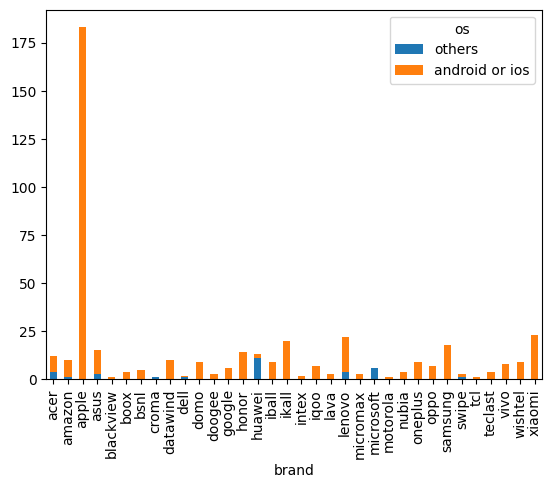

In [80]:
contig.iloc[:,-2:].plot(kind='bar', stacked = True)

In [81]:
contig["other %"] = np.round((contig["others"]/contig["total"]) * 100, 2)

In [82]:
contig["main %"] = np.round((contig["android or ios"]/contig["total"]) * 100, 2)

<Axes: title={'center': 'Proportions of main (android or ios) os vs other os'}, xlabel='brand'>

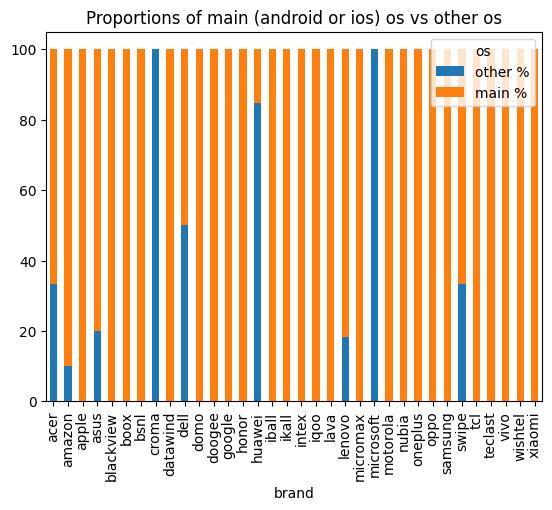

In [83]:
contig.iloc[:, -2:].plot(kind='bar',stacked=True, title = "Proportions of main (android or ios) os vs other os")

In [84]:
contig.loc[['acer','amazon','asus','croma','dell','huawei','lenovo','microsoft','swipe'],['main %','other %']]

os,main %,other %
brand,,
acer,66.67,33.33
amazon,90.00,10.00
asus,80.00,20.00
croma,0.00,100.00
dell,50.00,50.00
huawei,15.38,84.62
lenovo,81.82,18.18
microsoft,0.00,100.00
swipe,66.67,33.33


In [85]:
to_impute_other = ['acer','amazon','asus','croma','dell','huawei','lenovo','microsoft','swipe']
random.seed(25)
def impute_os(row):
    if pd.isna(row['os']):
        if row['brand'] == 'apple':
            return 'ios'
        elif row['brand'] not in to_impute_other:
            return 'android'
        else:
            random_number = random.randint(0,100)
            if random_number <= contig.loc[row['brand'], 'main %']:
                return 'android'
            else:
                return 'other'
    else:
        return row['os']

In [86]:
tablets['os'] = tablets.apply(impute_os, axis=1)

In [87]:
tablets.drop(['fm_radio'], axis = 1, inplace = True)

In [88]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1538 entries, 0 to 1628
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1538 non-null   object 
 1   price         1538 non-null   object 
 2   spec_score    1537 non-null   float64
 3   user_rating   1534 non-null   float64
 4   cpu           1503 non-null   object 
 5   ram           1529 non-null   object 
 6   battery       1355 non-null   object 
 7   display       1534 non-null   object 
 8   camera        1538 non-null   object 
 9   expandable    1538 non-null   object 
 10  os            1538 non-null   object 
 11  img           1538 non-null   object 
 12  connectivity  1531 non-null   object 
 13  has_sim       1538 non-null   int64  
 14  brand         1538 non-null   object 
dtypes: float64(2), int64(1), object(12)
memory usage: 224.5+ KB


In [89]:
# fill spec_score and user_rating

In [90]:
tablets['price'] = tablets['price'].astype(np.int32)
tablets.reset_index(inplace=True)

In [91]:
tablets['idx'] = np.array(tablets.index).T
tablets['idx'] = tablets['idx'].astype(np.int16)

to_impute = tablets[['price','user_rating','spec_score']].copy()
imputer = IterativeImputer(estimator=LinearRegression(), random_state=0)
imputed_data = imputer.fit_transform(to_impute)
imputed_df = pd.DataFrame(imputed_data)

imputed_df['idx'] = (np.array(imputed_df.index).T).astype(np.int16)
imputed_df = imputed_df.rename({
    0:'price',
    1:'user_rating',
    2:'spec_score'
}, axis = 1)

In [92]:
tablets = tablets.merge(imputed_df, on='idx')

In [93]:
tablets.columns

Index(['index', 'name', 'price_x', 'spec_score_x', 'user_rating_x', 'cpu',
       'ram', 'battery', 'display', 'camera', 'expandable', 'os', 'img',
       'connectivity', 'has_sim', 'brand', 'idx', 'price_y', 'user_rating_y',
       'spec_score_y'],
      dtype='object')

In [94]:
tablets = tablets.drop(['index','price_x', 'spec_score_x', 'user_rating_x','idx'], axis=1)

In [95]:
tablets = tablets.rename({
    'price_y' : 'price',
    'user_rating_y' : 'user_rating',
    'spec_score_y' : 'spec_score'
}, axis = 1)

In [96]:
tablets.head(1)

,name,cpu,ram,battery,display,camera,expandable,os,img,connectivity,has_sim,brand,price,user_rating,spec_score
0,Samsung Galaxy Tab A9 Plus Tablet (5G+ 8GB RAM...,"Snapdragon 695, Octa Core, 2.2 GHz Processor","8 GB RAM, 128 GB inbuilt",7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-icHlvG2Xk-w280-h...,"3G, 4G, 5G, Wi-Fi",1,samsung,17905.0,4.75,76.0


In [97]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1538 non-null   object 
 1   cpu           1503 non-null   object 
 2   ram           1529 non-null   object 
 3   battery       1355 non-null   object 
 4   display       1534 non-null   object 
 5   camera        1538 non-null   object 
 6   expandable    1538 non-null   object 
 7   os            1538 non-null   object 
 8   img           1538 non-null   object 
 9   connectivity  1531 non-null   object 
 10  has_sim       1538 non-null   int64  
 11  brand         1538 non-null   object 
 12  price         1538 non-null   float64
 13  user_rating   1538 non-null   float64
 14  spec_score    1538 non-null   float64
dtypes: float64(3), int64(1), object(11)
memory usage: 180.4+ KB


In [98]:
pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

In [99]:
tablets['cpu'].value_counts()

cpu
Quad Core, 1.3 GHz Processor                          93
Dual Core, 1 GHz Processor                            59
Single Core, 1 GHz Processor                          51
Quad Core, 1.2 GHz Processor                          49
Helio G99, Octa Core, 2.2 GHz Processor               38
Single Core, 1.2 GHz Processor                        37
Dual Core, 1.3 GHz Processor                          35
Dual Core, 1.2 GHz Processor                          34
Apple M2, Octa Core Processor                         30
Apple M1, Octa Core Processor                         23
Snapdragon 680, Octa Core, 2.4 GHz Processor          22
Snapdragon 870, Octa Core, 3.2 GHz Processor          17
Apple, Dual Core, 1.3 GHz Processor                   17
Snapdragon 450, Octa Core, 1.8 GHz Processor          16
Dual Core, 1.5 GHz Processor                          16
Apple M3, Octa Core Processor                         15
Octa Core, 2 GHz Processor                            15
Octa Core Processor        

In [100]:
tablets['cpu_brand'] = tablets['cpu'].str.split(',').str.get(0).str.strip()

In [101]:
tablets['cpu_cores'] = tablets['cpu'].str.split(',').str.get(1).str.strip()

In [102]:
tablets['cpu_speed'] = tablets['cpu'].str.split(',').str.get(2).str.strip()

In [103]:
tablets['cpu_brand'].value_counts().sort_index()

cpu_brand
(12 nm)                    1
1.3 GHz Processor          3
4000                       1
64-bit                     1
6575                       1
8125                       1
8312                       1
A12                        1
A12Z Bionic               14
A12x                       2
APQ8028                    1
ARM Cortex A7              1
Allwinner  B300            1
Allwinner A133             1
Allwinner A523             1
Apple                     44
Apple  A12                 1
Apple A12                  7
Apple A12X                14
Apple A14                  1
Apple APL1021              2
Apple M1                  23
Apple M2                  30
Apple M3                  15
Apple M4                  17
Apple M5                   1
Bionic  A15                4
Bionic A13                 4
Bionic A14                 4
Bionic A15                 1
Bionic A16                 6
Bionic A17                 3
Bionic A17 Pro             5
Celeron   N4000            2
Cele

In [104]:
for idx in tablets['cpu_brand'].value_counts().sort_index().index:
    if 'apple'.lower() in idx.lower():
        print(idx)

Apple
Apple  A12
Apple A12
Apple A12X
Apple A14
Apple APL1021
Apple M1
Apple M2
Apple M3
Apple M4
Apple M5


In [105]:
def shift_values(from_column, to_column, value_to_look):
    values_idx = tablets[tablets[from_column].apply(lambda x: True if ((isinstance(x,str)) and (value_to_look.lower() in x.lower())) else False)].index
    tablets.loc[values_idx, to_column] = tablets.loc[values_idx, from_column] 
    tablets.loc[values_idx, from_column] = np.nan

In [106]:
def rename_values(column,to_change,new_value):
    if isinstance(to_change,tuple):
        rename_idx = tablets[tablets[column].isin(to_change)].index
        tablets.loc[rename_idx, column] = new_value
    else:
        rename_idx = tablets[tablets[column] == to_change].index
        tablets.loc[rename_idx, column] = new_value

In [107]:
shift_values('cpu_brand','cpu_speed','ghz')

In [108]:
shift_values('cpu_cores','cpu_speed', 'ghz')

In [109]:
rename_values('cpu_brand','Core i9','Intel i9')

In [110]:
shift_values('cpu_brand','cpu_cores', 'core')

In [111]:
rename_values('cpu_brand',('(12 nm)', '4000', '64-bit', '6575', '8125', '8312'),np.nan)

In [112]:
rename_values('cpu_brand',('A12', 'Apple  A12', 'Apple A12'),'Bionic A12')

In [113]:
rename_values('cpu_brand',('A12x', 'Apple A12X'),'Bionic A12X')

In [114]:
rename_values('cpu_brand','A12Z Bionic','Bionic A12Z')

In [115]:
rename_values('cpu_brand','Apple APL1021','Bionic A9X')

In [116]:
tablets['cpu_brand'] = tablets['cpu_brand'].str.replace('Apple', 'Bionic').str.replace('  ', ' ').str.replace('  ', ' ').str.replace('\u200b','')

In [117]:
rename_values('cpu_brand','APQ8028','Snapdragon 400 APQ8028')

In [118]:
rename_values('cpu_brand','CortexA53','Cortex A53')

In [119]:
rename_values('cpu_brand','MT8161','Helio MT8161')
rename_values('cpu_brand','MT8165','Helio MT8165')
rename_values('cpu_brand','MT8389','Helio MT8389')
rename_values('cpu_brand','MT8735V','Helio MT8735V')
rename_values('cpu_brand','MT8765B','Helio MT8765B')
rename_values('cpu_brand','MT8766WA','Helio MT8766WA')
rename_values('cpu_brand','MTK 6750','Helio MTK 6750')
rename_values('cpu_brand','MTK8735','Helio MTK8735')

In [120]:
rename_values('cpu_brand','PXA1088','Marvell PXA1088')
rename_values('cpu_brand','PXA986','Marvell PXA986')

In [121]:
rename_values('cpu_brand','SC7731C','Spreadtrum SC7731C')
rename_values('cpu_brand','SC9832','Spreadtrum SC9832')
rename_values('cpu_brand','SC9863','Spreadtrum SC9863')
rename_values('cpu_brand','SC9863A','Spreadtrum SC9863A')

In [122]:
rename_values('cpu_brand','Z3735G','Intel Z3735G')
rename_values('cpu_brand','x5Z8550','Intel x5Z8550')

In [123]:
temp = tablets['cpu_brand'].str.split().str.get(0).value_counts()

In [124]:
temp

cpu_brand
Helio         242
Snapdragon    215
Bionic        199
Kirin          40
Intel          39
Tiger          38
Dimensity      37
Exynos         36
Fusion         20
Unisoc         15
Spreadtrum      9
Cortex          8
Kompanio        7
Marvell         5
Tensor          4
Celeron         4
Allwinner       3
Nvidia          2
ARM             1
UNISOC          1
Xring           1
Google          1
Rockchip        1
Name: count, dtype: int64

In [125]:
other_cpu_list = list(temp[temp <= 20].index)

In [126]:
other_cpu_list

['Fusion',
 'Unisoc',
 'Spreadtrum',
 'Cortex',
 'Kompanio',
 'Marvell',
 'Tensor',
 'Celeron',
 'Allwinner',
 'Nvidia',
 'ARM',
 'UNISOC',
 'Xring',
 'Google',
 'Rockchip']

In [127]:
other_cpu_idx = tablets[tablets['cpu_brand'].apply(lambda x: True if ((isinstance(x,str)) and (x.split()[0] in other_cpu_list)) else False)].index

In [128]:
tablets.loc[other_cpu_idx,'cpu_brand'] = 'Other'

In [129]:
tablets.drop(['cpu'], axis=1, inplace = True)

In [130]:
tablets.rename({'cpu_brand':'cpu'}, axis = 1, inplace=True)

In [131]:
tablets['cpu_brand'] = tablets['cpu'].str.split().str.get(0)

In [132]:
tablets.head(2)

,name,ram,battery,display,camera,expandable,os,img,connectivity,has_sim,brand,price,user_rating,spec_score,cpu,cpu_cores,cpu_speed,cpu_brand
0,Samsung Galaxy Tab A9 Plus Tablet (5G+ 8GB RAM...,"8 GB RAM, 128 GB inbuilt",7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-icHlvG2Xk-w280-h...,"3G, 4G, 5G, Wi-Fi",1,samsung,17905.0,4.75,76.0,Snapdragon 695,Octa Core,2.2 GHz Processor,Snapdragon
1,Samsung Galaxy Tab S9 FE Plus 2023 (Wi-Fi Only...,"8 GB RAM, 128 GB inbuilt",10090 mAh Battery with 45W Fast Charging,"12.4 inches, 1600 x 2560 px, 120 Hz Display",8 MP + 8 MP Dual Rear & 12 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-iA0C7Qr5k-w280-h...,Wi-Fi,0,samsung,32628.0,4.75,78.0,Exynos 1380,Octa Core,2.4 GHz Processor,Exynos


In [133]:
tablets['cpu_cores'].value_counts().sort_index()

cpu_cores
Deca Core                  1
Deca Core Processor       12
Dual Core                246
Dual Core Processor        3
Hexa Core                 51
Hexa Core Processor        6
Nine Core Processor        5
Octa Core                542
Octa Core Processor      104
Quad Core                370
Quad Core Processor       19
Single Core              115
Single Core Processor      8
Triple Core                4
Name: count, dtype: int64

In [134]:
tablets['cpu_cores'] = tablets['cpu_cores'].str.replace(' Processor', '')

In [135]:
tablets['cpu_cores'] = tablets['cpu_cores'].str.split().str.get(0)

In [136]:
def core_mapping(cores):
    if cores == 'Deca':
        return 10
    elif cores == 'Dual':
        return 2
    elif cores == 'Hexa':
        return 6
    elif cores == 'Nine':
        return 9
    elif cores == 'Octa':
        return 8
    elif cores == 'Quad':
        return 4
    elif cores == 'Single':
        return 1
    elif cores == 'Triple':
        return 3

In [137]:
tablets['cpu_cores'] = tablets['cpu_cores'].apply(core_mapping)

In [138]:
tablets['cpu_speed'].value_counts().sort_index()

cpu_speed
1.1 GHz Processor      11
1.22 GHz Processor      1
1.28 GHz Processor      3
1.2 GHz Processor     141
1.33 GHz Processor      7
1.34 GHz Processor      2
1.3 GHz Processor     217
1.4 GHz Processor      20
1.5 GHz Processor      57
1.66 GHz Processor      1
1.6 GHz Processor      48
1.7 GHz Processor       9
1.83 GHz Processor     13
1.84 GHz Processor      5
1.86 GHz Processor      6
1.8 GHz Processor      46
1.92 GHz Processor      1
1.99 GHz Processor      1
1.9 GHz Processor       7
1 GHz Processor       140
2.05 GHz Processor      6
2.16 GHz Processor      6
2.1 GHz Processor       2
2.24 GHz Processor      3
2.26 GHz Processor      5
2.27 GHz Processor      3
2.2 GHz Processor      72
2.34 GHz Processor      8
2.35 GHz Processor      1
2.36 GHz Processor      6
2.38 GHz Processor     12
2.3 GHz Processor      30
2.49 GHz Processor     11
2.4 GHz Processor      57
2.56 GHz Processor      1
2.58 GHz Processor      1
2.5 GHz Processor      31
2.62 GHz Processor      3
2.

In [139]:
tablets['cpu_speed'] = tablets['cpu_speed'].str.split().str.get(0)

In [140]:
tablets['cpu_speed'] = tablets['cpu_speed'].astype(float)

In [141]:
tablets['ram'].value_counts()

ram
1 GB RAM, 8 GB inbuilt                                                            145
4 GB RAM, 64 GB inbuilt                                                           140
8 GB RAM, 128 GB inbuilt                                                          108
2 GB RAM, 16 GB inbuilt                                                           108
2 GB RAM, 32 GB inbuilt                                                           107
1 GB RAM, 16 GB inbuilt                                                           101
3 GB RAM, 32 GB inbuilt                                                           101
8 GB RAM, 256 GB inbuilt                                                           87
6 GB RAM, 128 GB inbuilt                                                           80
512 MB RAM, 4 GB inbuilt                                                           62
4 GB RAM, 128 GB inbuilt                                                           52
12 GB RAM, 256 GB inbuilt                         

In [142]:
tablets.rename({'ram':'storage'}, axis=1, inplace=True)

In [143]:
tablets['ram'] = tablets['storage'].str.split(',').str.get(0).apply(lambda x: x if ((isinstance(x,str)) and ('RAM' in x)) else np.nan).str.replace('30 GB (','').str.replace(' of physical RAM + 24GB of extended virtual RAM)','')

In [144]:
def get_rom(storage):
    if isinstance(storage,str):
        split = storage.split(",")
        if 'inbuilt' in split[0]:
            return split[0]
        elif len(split) > 1:
            if 'inbuilt' in split[1]:
                return split[1]
        else:
            return np.nan
    else:
        return np.nan

In [145]:
tablets['inbuilt_storage'] = tablets['storage'].apply(get_rom)

In [146]:
tablets['ram'] = tablets['ram'].str.split(' ').str.get(0).str.split().str.get(0).str.replace('GB','').astype(float).apply(lambda x: x if x<21 else round(x/1024,2))

In [147]:
tablets['inbuilt_storage'] = tablets['inbuilt_storage'].str.strip()

In [148]:
tablets['inbuilt_storage'].value_counts()

inbuilt_storage
128 GB inbuilt     263
32 GB inbuilt      259
16 GB inbuilt      241
64 GB inbuilt      205
8 GB inbuilt       190
256 GB inbuilt     171
4 GB inbuilt       108
512 GB inbuilt      35
1 TB inbuilt        26
2 TB inbuilt        13
2 GB inbuilt         4
1 GB inbuilt         2
512 MB inbuilt       2
60 GB inbuilt        1
1.15 GB inbuilt      1
1.65 GB inbuilt      1
2.5 GB inbuilt       1
Name: count, dtype: int64

In [149]:
rename_values(column='inbuilt_storage', to_change='1 TB inbuilt', new_value='1024 GB inbuilt')
rename_values(column='inbuilt_storage', to_change='2 TB inbuilt', new_value='2048 GB inbuilt')

In [150]:
tablets['inbuilt_storage'] = tablets['inbuilt_storage'].str.split().str.get(0).astype(float)

In [151]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1538 non-null   object 
 1   storage          1529 non-null   object 
 2   battery          1355 non-null   object 
 3   display          1534 non-null   object 
 4   camera           1538 non-null   object 
 5   expandable       1538 non-null   object 
 6   os               1538 non-null   object 
 7   img              1538 non-null   object 
 8   connectivity     1531 non-null   object 
 9   has_sim          1538 non-null   int64  
 10  brand            1538 non-null   object 
 11  price            1538 non-null   float64
 12  user_rating      1538 non-null   float64
 13  spec_score       1538 non-null   float64
 14  cpu              928 non-null    object 
 15  cpu_cores        1486 non-null   float64
 16  cpu_speed        1332 non-null   float64
 17  cpu_brand     

In [152]:
tablets.head(2)

,name,storage,battery,display,camera,expandable,os,img,connectivity,has_sim,brand,price,user_rating,spec_score,cpu,cpu_cores,cpu_speed,cpu_brand,ram,inbuilt_storage
0,Samsung Galaxy Tab A9 Plus Tablet (5G+ 8GB RAM...,"8 GB RAM, 128 GB inbuilt",7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-icHlvG2Xk-w280-h...,"3G, 4G, 5G, Wi-Fi",1,samsung,17905.0,4.75,76.0,Snapdragon 695,8.0,2.2,Snapdragon,8.0,128.0
1,Samsung Galaxy Tab S9 FE Plus 2023 (Wi-Fi Only...,"8 GB RAM, 128 GB inbuilt",10090 mAh Battery with 45W Fast Charging,"12.4 inches, 1600 x 2560 px, 120 Hz Display",8 MP + 8 MP Dual Rear & 12 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-iA0C7Qr5k-w280-h...,Wi-Fi,0,samsung,32628.0,4.75,78.0,Exynos 1380,8.0,2.4,Exynos,8.0,128.0


In [153]:
tablets.drop(['storage'], axis = 1, inplace = True)

In [154]:
tablets['battery_capacity'] = tablets['battery'].str.split('mAh').str.get(0).str.strip().str.replace('Battery: ','')

In [155]:
tablets['fast_charging'] = tablets['battery'].str.split('mAh').str.get(1).str.strip().str.replace('Battery with ','').str.split('Fast').str.get(0).str.replace("W","")

In [156]:
tablets['fast_charging'].value_counts()

fast_charging
Battery                         916
                                 81
18                               77
45                               71
15                               36
33                               34
67                               21
20                               21
10                               18
22.5                             17
66                               15
44                                9
40                                6
120                               5
35                                5
68                                5
30                                5
80                                3
100                               3
25                                2
65                                1
88                                1
55                                1
Lithium Polymer batterie          1
Rechargeable Polymer Battery      1
Name: count, dtype: int64

In [157]:
def change_fastch(value):
    if isinstance(value,str):
        if value in ('Battery','Lithium Polymer batterie','Rechargeable Polymer Battery'):
            return 0
        elif value == '':
            return 1
        else:
            return value

In [158]:
tablets['fast_charging'] = tablets['fast_charging'].apply(change_fastch)

In [159]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1538 non-null   object 
 1   battery           1355 non-null   object 
 2   display           1534 non-null   object 
 3   camera            1538 non-null   object 
 4   expandable        1538 non-null   object 
 5   os                1538 non-null   object 
 6   img               1538 non-null   object 
 7   connectivity      1531 non-null   object 
 8   has_sim           1538 non-null   int64  
 9   brand             1538 non-null   object 
 10  price             1538 non-null   float64
 11  user_rating       1538 non-null   float64
 12  spec_score        1538 non-null   float64
 13  cpu               928 non-null    object 
 14  cpu_cores         1486 non-null   float64
 15  cpu_speed         1332 non-null   float64
 16  cpu_brand         928 non-null    object 


In [160]:
tablets['battery_capacity'] = tablets['battery_capacity'].astype(float)
tablets['fast_charging'] = tablets['fast_charging'].astype(float)

In [161]:
tablets.head(2)

,name,battery,display,camera,expandable,os,img,connectivity,has_sim,brand,price,user_rating,spec_score,cpu,cpu_cores,cpu_speed,cpu_brand,ram,inbuilt_storage,battery_capacity,fast_charging
0,Samsung Galaxy Tab A9 Plus Tablet (5G+ 8GB RAM...,7040 mAh Battery with 15W Fast Charging,"11 inches, 1200 x 1920 px, 90 Hz Display",8 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-icHlvG2Xk-w280-h...,"3G, 4G, 5G, Wi-Fi",1,samsung,17905.0,4.75,76.0,Snapdragon 695,8.0,2.2,Snapdragon,8.0,128.0,7040.0,15.0
1,Samsung Galaxy Tab S9 FE Plus 2023 (Wi-Fi Only...,10090 mAh Battery with 45W Fast Charging,"12.4 inches, 1600 x 2560 px, 120 Hz Display",8 MP + 8 MP Dual Rear & 12 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v13,https://cdn1.smartprix.com/rx-iA0C7Qr5k-w280-h...,Wi-Fi,0,samsung,32628.0,4.75,78.0,Exynos 1380,8.0,2.4,Exynos,8.0,128.0,10090.0,45.0


In [162]:
tablets.drop(['battery'], axis = 1, inplace = True)

In [163]:
tablets['screen_size'] = tablets['display'].str.replace('Display','').str.split(',').str.get(0)

In [164]:
tablets['screen_res'] = tablets['display'].str.replace('Display','').str.split(',').str.get(1)

In [165]:
tablets['screen_refresh_rate'] = tablets['display'].str.replace('Display','').str.split(',').str.get(2)

In [166]:
tablets['screen_refresh_rate'] = tablets['screen_refresh_rate'].str.split("Hz").str.get(0).apply(lambda x: 60 if pd.isna(x) else x).astype(np.int16)

In [167]:
tablets['screen_size'] = tablets['screen_size'].str.strip()

In [168]:
tablets['screen_size'].value_counts()

screen_size
7 inches                     376
10.1 inches                  212
8 inches                     158
11 inches                    128
12.9 inches                   46
9.69 inches                   41
7.9 inches                    38
10.4 inches                   38
13 inches                     34
11.5 inches                   27
12.1 inches                   25
10.5 inches                   24
12.4 inches                   21
9.7 inches                    18
10.95 inches                  18
10.9 inches                   18
10.3 inches                   17
10 inches                     15
8.7 inches                    14
9 inches                      13
12.7 inches                   11
12.2 inches                   11
10.61 inches                  10
10.8 inches                   10
14.6 inches                   10
10.2 inches                   10
10.6 inches                   10
8.3 inches                    10
12 inches                     10
8.4 inches                    1

In [169]:
shift_values('screen_size', 'screen_res', '1280 x 800 px')

In [170]:
shift_values('screen_size', 'screen_res', '1024 x 600 px')

In [171]:
shift_values('screen_size', 'screen_res', '800 x 480 px')

In [172]:
shift_values('screen_size', 'screen_res', '480 x 800 px')

In [173]:
tablets['screen_res'] = tablets['screen_res'].str.split('px').str.get(0).str.strip()

In [174]:
tablets['screen_res'].value_counts()

screen_res
800 x 1280     144
600 x 1024     141
1280 x 800     127
1200 x 1920    106
1024 x 600     101
1536 x 2048     80
1200 x 2000     76
1920 x 1200     71
1600 x 2560     69
480 x 800       50
2048 x 2732     47
800 x 480       45
2560 x 1600     33
2000 x 1200     31
1640 x 2360     28
1668 x 2388     27
768 x 1024      27
800 x 1340      19
2732 x 2048     14
1800 x 2880     11
1848 x 2960     11
2064 x 2752     10
2944 x 1840     10
1080 x 1920      9
1668 x 2224      9
1280 x 720       9
1668 x 2420      8
1366 x 768       8
1440 x 2304      8
2800 x 1840      7
2388 x 1668      7
800 x 600        6
800 x 1200       6
2136 x 3200      6
1968 x 2800      6
2000 x 2800      5
2064 x 3096      5
1024 x 768       5
1920 x 1080      5
2160 x 1620      5
2120 x 3000      5
720 x 1280       5
1488 x 2266      5
1752 x 2800      5
1620 x 2160      5
1200 x 800       5
2266 x 1488      4
1720 x 2408      4
1840 x 2800      3
1440 x 2200      3
1860 x 2480      3
2400 x 3392      3
2

In [175]:
rename_values('screen_size','25.4 cm (10 inch) Full HD','10 inch')
rename_values('screen_size','17.78 cm (7 inch)','7 inch')

In [176]:
tablets['screen_size'] = tablets['screen_size'].str.split().str.get(0).astype(float)

In [177]:
tablets['screen_width'] = tablets['screen_res'].str.split('x').str.get(0).str.strip().astype(float)

In [178]:
tablets['screen_height'] = tablets['screen_res'].str.split('x').str.get(1).str.strip().astype(float)

In [179]:
# creating an additional column of 'ppi' which means pixel per inch.
# This can be calculated by : (length of diagonal)/(number of pixels in diagonal)
tablets['ppi'] = round(np.sqrt((tablets['screen_width']*tablets['screen_width']) + (tablets['screen_height']*tablets['screen_height']))/(tablets['screen_size']),2)

In [180]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 1538 non-null   object 
 1   display              1534 non-null   object 
 2   camera               1538 non-null   object 
 3   expandable           1538 non-null   object 
 4   os                   1538 non-null   object 
 5   img                  1538 non-null   object 
 6   connectivity         1531 non-null   object 
 7   has_sim              1538 non-null   int64  
 8   brand                1538 non-null   object 
 9   price                1538 non-null   float64
 10  user_rating          1538 non-null   float64
 11  spec_score           1538 non-null   float64
 12  cpu                  928 non-null    object 
 13  cpu_cores            1486 non-null   float64
 14  cpu_speed            1332 non-null   float64
 15  cpu_brand            928 non-null    o

In [181]:
tablets.drop(['display'], axis = 1, inplace = True)

In [182]:
tablets['rear'] = tablets['camera'].str.split('&').str.get(0).str.strip().str.replace('\u2009', '')
tablets['front'] = tablets['camera'].str.split('&').str.get(1).str.strip().str.replace('\u2009', '')

In [183]:
_ = list()
for camera in tablets['camera'].str.split('&').str.get(0).str.strip().str.replace('\u2009', '').unique():
    if isinstance(camera, str):
        if 'Front' in camera:
            _.append(camera)
_

['5MP Front Camera',
 '2MP Front Camera',
 '0.3MP Front Camera',
 '8MP Front Camera',
 '1.2MP Front Camera']

In [184]:
for value in _:
    shift_values('rear','front',value)

In [185]:
for camera in tablets['rear'].unique():
    if isinstance(camera, str):
        if 'Front' in camera:
            print(camera)

In [186]:
tablets['rear'].value_counts()

rear
8MP Rear                                  365
5MP Rear                                  340
13MP Rear                                 183
2MP Rear                                  181
12MP Rear                                 110
0.3MP Rear Camera                          39
12MP + 10MP + Depth Sensor Triple Rear     38
3.15MP Rear                                26
2MP Rear Camera                            24
13MP + 5MP Dual Rear                       18
13MP + 8MP Dual Rear                       16
12MP + 10MP Dual Rear                      14
No Rear Camera                             13
13MP + 2MP Dual Rear                       10
3MP Rear                                    9
16MP Rear                                   8
50MP Rear                                   8
0.3MP Rear                                  7
5MP Rear Camera                             7
0.7MP Rear                                  6
8MP Rear Camera                             6
1.3MP Rear Camera            

In [187]:
def count_camera(value):
    if isinstance(value,str):
        if 'no' in value.lower():
            return 0
        else:
            return (value.count("+") + 1)
    else:
        return 0

In [188]:
tablets['rear_cameras'] = tablets['rear'].apply(count_camera)

In [189]:
tablets['front_cameras'] = tablets['front'].apply(count_camera)

In [190]:
tablets['rear_primary'] = tablets['rear'].str.split('MP').str.get(0).str.strip()

In [191]:
tablets['rear_primary'].value_counts()

rear_primary
8                  375
5                  348
13                 246
2                  205
12                 164
0.3                 46
3.15                27
50                  21
16                  14
No Rear Camera      13
3                   10
1.3                  8
1.2                  7
0.7                  6
3.2                  5
20                   5
3.1                  4
48                   2
64                   1
1                    1
7                    1
1.9                  1
6.7                  1
13.0                 1
Wide Angle Rear      1
11                   1
Name: count, dtype: int64

In [192]:
rename_values('rear_primary','No Rear Camera',0)
rename_values('rear_primary','Wide Angle Rear',np.nan)

In [193]:
tablets['rear_primary'] = tablets['rear_primary'].astype(float)

In [194]:
tablets['front_primary'] = tablets['front'].str.split('MP').str.get(0).str.strip()

In [195]:
tablets['front_primary'].value_counts()

front_primary
2                          335
8                          245
5                          241
0.3                        209
12                         154
1.2                        103
7                           51
1.3                         31
1.6                         11
16                           9
13                           7
20                           5
32                           5
2.1                          5
3.2                          5
9                            4
3                            4
1.9                          3
1                            2
Wide Angle Front Camera      1
3.5                          1
Main Front Camera            1
Name: count, dtype: int64

In [196]:
rename_values('front_primary',('Wide Angle Front Camera', 'Main Front Camera'),np.nan)

In [197]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 1538 non-null   object 
 1   camera               1538 non-null   object 
 2   expandable           1538 non-null   object 
 3   os                   1538 non-null   object 
 4   img                  1538 non-null   object 
 5   connectivity         1531 non-null   object 
 6   has_sim              1538 non-null   int64  
 7   brand                1538 non-null   object 
 8   price                1538 non-null   float64
 9   user_rating          1538 non-null   float64
 10  spec_score           1538 non-null   float64
 11  cpu                  928 non-null    object 
 12  cpu_cores            1486 non-null   float64
 13  cpu_speed            1332 non-null   float64
 14  cpu_brand            928 non-null    object 
 15  ram                  1451 non-null   f

In [198]:
tablets['rear_cameras'] = tablets['rear_cameras'].astype(np.int8)
tablets['front_cameras'] = tablets['front_cameras'].astype(np.int8)
tablets['front_primary'] = tablets['front_primary'].astype(float)

In [199]:
np.array(tablets['expandable'].value_counts().index)

array([0, 'Memory Card Supported, upto 32\u2009GB',
       'Memory Card Supported, upto 1\u2009TB', 'Memory Card Supported',
       'Memory Card Not Supported',
       'Memory Card Supported, upto 64\u2009GB',
       'Memory Card Supported, upto 128\u2009GB',
       'Memory Card Supported, upto 256\u2009GB',
       'Memory Card Supported, upto 512\u2009GB',
       'Memory Card (Hybrid), upto 1\u2009TB',
       'Memory Card Supported, upto 2\u2009TB',
       'Memory Card Supported, upto 1.5\u2009TB', 'Memory Card (Hybrid)',
       'Memory Card (Hybrid), upto 512\u2009GB',
       'Memory Card (Hybrid), upto 2\u2009TB',
       'Memory Card Supported, upto 400\u2009GB',
       'Memory Card (Hybrid), upto 64\u2009GB',
       'Memory Card (Hybrid), upto 1.5\u2009TB',
       'Memory Card (Hybrid), upto 256\u2009GB',
       'Memory Card Supported, upto 1.02\u2009TB'], dtype=object)

In [200]:
tablets['expandable'] = tablets['expandable'].str.replace('\u2009','')

In [201]:
def modify_expandable(value):
    if isinstance(value,str):
        if bool(re.search(r'\d+(?:\.\d+)?', value)):
            if float(re.search(r'\d+(?:\.\d+)?', value).group()) > 5:
                return float(re.search(r'\d+(?:\.\d+)?', value).group())
            else:
                return float(re.search(r'\d+(?:\.\d+)?', value).group())*1024
        elif value in ('Memory Card (Hybrid)','Memory Card Supported'):
            return 1
        elif value == 'Memory Card Not Supported':
            return 0
    else:
        return value

In [202]:
tablets['expandable'] = tablets['expandable'].apply(modify_expandable)

In [203]:
tablets['expandable'].value_counts()

expandable
32.00      349
1024.00    181
1.00       143
0.00       116
64.00      111
128.00      94
256.00      78
512.00      69
2048.00     14
1536.00      8
400.00       4
1044.48      1
Name: count, dtype: int64

In [204]:
tablets['os'].value_counts().sort_index()

os
Android v10                      11
Android v11                      11
Android v12                      14
Android v13                      39
Android v13.1                     2
Android v14                      22
Android v15                      27
Android v16                       1
Android v2.3 (Gingerbread)        3
Android v3 (Honeycomb)            1
Android v3.0 (Honeycomb)          2
Android v3.1 (Honeycomb)          3
Android v3.2 (Honeycomb)          3
Android v4 (ICS)                  1
Android v4.0 (ICS)               13
Android v4.0.3 (ICS)              3
Android v4.0.4 (ICS)              3
Android v4.1 (Jelly Bean)         6
Android v4.1.1 (Jelly Bean)       1
Android v4.2 (Jelly Bean)         4
Android v4.2.2 (Jelly Bean)       4
Android v4.3 (Jelly Bean)         1
Android v4.4 (KitKat)             2
Android v4.4. (KitKat)            1
Android v4.4.2 (KitKat)          14
Android v5.0 (Lollipop)           1
Android v6.0 (Marshmallow)       15
Android v6.0.1 (Marshmall

In [205]:
tablets['os'] = tablets['os'].apply(lambda x: 'android' if 'android' in x.lower() else 'ios' if ('ios' in x.lower()) or ('ipad' in x.lower()) else 'other')

In [206]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 1538 non-null   object 
 1   camera               1538 non-null   object 
 2   expandable           1168 non-null   float64
 3   os                   1538 non-null   object 
 4   img                  1538 non-null   object 
 5   connectivity         1531 non-null   object 
 6   has_sim              1538 non-null   int64  
 7   brand                1538 non-null   object 
 8   price                1538 non-null   float64
 9   user_rating          1538 non-null   float64
 10  spec_score           1538 non-null   float64
 11  cpu                  928 non-null    object 
 12  cpu_cores            1486 non-null   float64
 13  cpu_speed            1332 non-null   float64
 14  cpu_brand            928 non-null    object 
 15  ram                  1451 non-null   f

In [207]:
tablets['connectivity'].value_counts()

connectivity
Wi-Fi                            501
3G, Wi-Fi                        268
3G, 4G, VoLTE, Wi-Fi             259
3G, 4G, Wi-Fi                    197
3G, 4G, 5G, VoLTE, Wi-Fi          74
Wi-Fi, HDMI                       64
3G, 4G, 5G, Wi-Fi                 44
3G, Wi-Fi, HDMI                   42
Wi-Fi, NFC                        22
3G, 4G, Wi-Fi, NFC                16
Wi-Fi, HDMI, NFC                   7
3G, 4G, Wi-Fi, HDMI                6
Wi-Fi, IR Blaster                  6
3G, 4G, 5G, VoLTE, Wi-Fi, NFC      5
VoLTE, Wi-Fi                       5
3G, 4G, Wi-Fi, HDMI, NFC           4
3G, VoLTE, Wi-Fi                   3
3G, Wi-Fi, NFC                     3
3G, 4G, Wi-Fi, IR Blaster          2
3G, 4G, 5G, Wi-Fi, NFC             1
3G, 4G, VoLTE, Wi-Fi, HDMI         1
4G, Wi-Fi                          1
Name: count, dtype: int64

In [208]:
tablets['has_5G'] = tablets['connectivity'].apply(lambda x: 1 if (isinstance(x,str)) and ('5G' in x) else 0).astype(np.int8)

In [209]:
tablets['has_nfc'] = tablets['connectivity'].apply(lambda x: 1 if (isinstance(x,str)) and ('NFC' in x) else 0).astype(np.int8)

In [210]:
tablets['has_irblaster'] = tablets['connectivity'].apply(lambda x: 1 if (isinstance(x,str)) and ('IR Blaster' in x) else 0).astype(np.int8)

In [215]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 1538 non-null   object 
 1   camera               1538 non-null   object 
 2   expandable           1168 non-null   float64
 3   os                   1538 non-null   object 
 4   img                  1538 non-null   object 
 5   connectivity         1531 non-null   object 
 6   has_sim              1538 non-null   int64  
 7   brand                1538 non-null   object 
 8   price                1538 non-null   float64
 9   user_rating          1538 non-null   float64
 10  spec_score           1538 non-null   float64
 11  cpu                  928 non-null    object 
 12  cpu_cores            1486 non-null   float64
 13  cpu_speed            1332 non-null   float64
 14  cpu_brand            928 non-null    object 
 15  ram                  1451 non-null   f

In [218]:
def label_resolution(w, h):
    width, height = sorted([int(w), int(h)])
    
    if width <= 854:
        return "SD"          
    elif width <= 960:
        return "qHD"        
    elif width <= 1280 and height <= 800:
        return "HD"          
    elif width <= 1280:
        return "HD+"         
    elif width <= 1080 and height <= 1920:
        return "FHD"         
    elif width <= 1080:
        return "FHD+"        
    elif width <= 1440:
        return "2K"        
    elif width <= 1600 and height <= 2560:
        return "WQXGA"       
    elif width <= 1800:
        return "3K"          
    elif width <= 2160:
        return "WQHD+"     
    elif width <= 3840:
        return "4K UHD"      
    else:
        return "Ultra HD+"   

In [230]:
tablets['screen_res'] = tablets.apply(lambda row: label_resolution(row['screen_width'], row['screen_height']) if (not pd.isna(row['screen_width'])) else np.nan, axis = 1).astype('category')

In [231]:
tablets.drop(
    ['camera','connectivity','screen_width','screen_height','rear','front'],
    axis = 1,
    inplace=True
)

In [239]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   name                 1538 non-null   object  
 1   expandable           1168 non-null   float64 
 2   os                   1538 non-null   category
 3   img                  1538 non-null   object  
 4   has_sim              1538 non-null   int8    
 5   brand                1538 non-null   category
 6   price                1538 non-null   float64 
 7   user_rating          1538 non-null   float64 
 8   spec_score           1538 non-null   float64 
 9   cpu                  928 non-null    object  
 10  cpu_cores            1486 non-null   float64 
 11  cpu_speed            1332 non-null   float64 
 12  cpu_brand            928 non-null    category
 13  ram                  1451 non-null   float64 
 14  inbuilt_storage      1523 non-null   float64 
 15  battery_capacity     

In [238]:
tablets['os'] = tablets['os'].astype('category')
tablets['brand'] = tablets['brand'].astype('category')
tablets['has_sim'] = tablets['has_sim'].astype(np.int8)
tablets['cpu_brand'] = tablets['cpu_brand'].astype('category')
tablets['screen_res'] = tablets['screen_res'].astype('category')

In [241]:
list(tablets.columns)

['name',
 'expandable',
 'os',
 'img',
 'has_sim',
 'brand',
 'price',
 'user_rating',
 'spec_score',
 'cpu',
 'cpu_cores',
 'cpu_speed',
 'cpu_brand',
 'ram',
 'inbuilt_storage',
 'battery_capacity',
 'fast_charging',
 'screen_size',
 'screen_res',
 'screen_refresh_rate',
 'ppi',
 'rear_cameras',
 'front_cameras',
 'rear_primary',
 'front_primary',
 'has_5G',
 'has_nfc',
 'has_irblaster']

In [246]:
tablets = tablets[[
    'name',
    'brand',
    'os',
    'cpu_brand',
    'cpu',
    'cpu_cores',
    'cpu_speed',
    'has_sim',
    'has_5G',
    'has_nfc',
    'has_irblaster',
    'ram',
    'inbuilt_storage',
    'battery_capacity',
    'fast_charging',
    'screen_size',
    'screen_res',
    'screen_refresh_rate',
    'ppi',
    'rear_cameras',
    'rear_primary',
    'front_cameras',
    'front_primary',
    'expandable',
    'spec_score',
    'user_rating',
    'price',
    'img'
]]         # arranged the columns

In [247]:
tablets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   name                 1538 non-null   object  
 1   brand                1538 non-null   category
 2   os                   1538 non-null   category
 3   cpu_brand            928 non-null    category
 4   cpu                  928 non-null    object  
 5   cpu_cores            1486 non-null   float64 
 6   cpu_speed            1332 non-null   float64 
 7   has_sim              1538 non-null   int8    
 8   has_5G               1538 non-null   int8    
 9   has_nfc              1538 non-null   int8    
 10  has_irblaster        1538 non-null   int8    
 11  ram                  1451 non-null   float64 
 12  inbuilt_storage      1523 non-null   float64 
 13  battery_capacity     1355 non-null   float64 
 14  fast_charging        1355 non-null   float64 
 15  screen_size          

In [249]:
# now time for some post cleaning analysis to find any other problems.
tablets['os'].value_counts()

os
android    1142
ios         254
other       142
Name: count, dtype: int64

In [253]:
np.round(tablets.describe().T,2)  # price column seems to be rightly skewed

,count,mean,std,min,25%,50%,75%,max
cpu_cores,1486.0,5.30,2.69,1.00,2.25,4.00,8.00,10.00
cpu_speed,1332.0,1.83,0.68,1.00,1.30,1.80,2.26,4.32
has_sim,1538.0,0.64,0.48,0.00,0.00,1.00,1.00,1.00
has_5G,1538.0,0.08,0.27,0.00,0.00,0.00,0.00,1.00
has_nfc,1538.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
has_irblaster,1538.0,0.01,0.07,0.00,0.00,0.00,0.00,1.00
ram,1451.0,3.86,3.41,0.25,1.00,3.00,6.00,20.00
inbuilt_storage,1523.0,98.70,159.71,1.00,16.00,32.00,128.00,1024.00
battery_capacity,1355.0,6080.97,2623.26,180.00,3950.00,6000.00,8000.00,22000.00
fast_charging,1355.0,9.15,18.77,0.00,0.00,0.00,10.00,120.00


<Axes: >

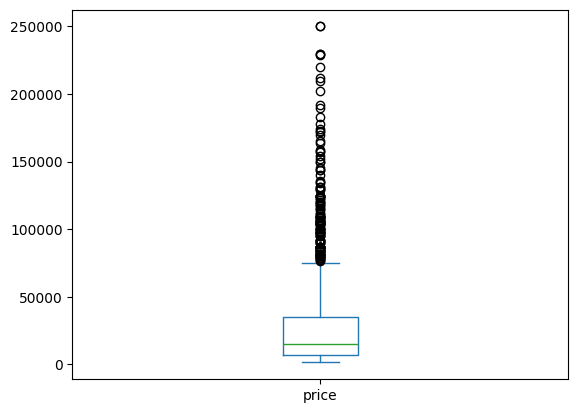

In [255]:
tablets['price'].plot.box()

In [274]:
tablets[tablets['price'] > 75000]['brand'].value_counts()  # most of these come from high end brands or their flagship products.
# so, technically these are not really outliers.

brand
apple         105
samsung        22
microsoft       4
boox            2
huawei          2
google          2
nubia           2
lenovo          1
asus            1
acer            0
oneplus         0
micromax        0
motorola        0
nokia           0
nothing         0
poco            0
oppo            0
jio             0
realme          0
swipe           0
tcl             0
teclast         0
tecno           0
vivo            0
wishtel         0
lava            0
intex           0
itel            0
dell            0
amtrak          0
blackberry      0
blackview       0
bsnl            0
byond           0
croma           0
cubot           0
datawind        0
domo            0
iqoo            0
doogee          0
fusion5         0
honor           0
htc             0
iball           0
ikall           0
infinix         0
amazon          0
xiaomi          0
Name: count, dtype: int64

In [276]:
dbo = Database(database = 'project')
dbo.create_table(tablets,'tablets')
dbo.close()